# 07 — Bayesian Learning and Inference

Bayesian learning provides a principled framework for reasoning about uncertainty.
Instead of treating model parameters as fixed but unknown quantities, Bayesian
inference represents uncertainty about parameters using probability distributions.

The central idea is Bayes' theorem:

$$
p(\theta \mid D)
=
\frac{p(D \mid \theta)p(\theta)}
{p(D)}
$$

where:

- $\theta$ represents unknown model parameters.
- $D$ represents observed data.
- $p(\theta)$ is the prior distribution.
- $p(D \mid \theta)$ is the likelihood.
- $p(\theta \mid D)$ is the posterior distribution.
- $p(D)$ is the marginal likelihood or evidence.

This notebook develops Bayesian learning from first principles and gradually
moves toward practical probabilistic machine learning.

## Learning Objectives

By the end of this notebook, we will understand:

1. Bayes' theorem and Bayesian updating.
2. Prior, likelihood, posterior, and evidence.
3. Maximum Likelihood Estimation (MLE).
4. Maximum A Posteriori (MAP) estimation.
5. Conjugate Bayesian models.
6. Posterior predictive inference.
7. Bayesian regression.
8. Approximate inference and MCMC.
9. Bayesian uncertainty quantification.
10. Bayesian model comparison and decision theory.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.special import expit

np.random.seed(42)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

## 3. What Is Bayesian Learning?

Suppose we want to estimate an unknown parameter $\theta$ from observed data $D$.

A frequentist approach typically treats $\theta$ as a fixed but unknown value and
estimates it from the data.

A Bayesian approach treats $\theta$ as uncertain and represents this uncertainty
with a probability distribution.

The Bayesian workflow is:

$$
\text{Prior}
\rightarrow
\text{Likelihood}
\rightarrow
\text{Posterior}
\rightarrow
\text{Prediction}
$$

### Prior

The prior represents what we believe about the parameter before observing the
current dataset.

$$
p(\theta)
$$

### Likelihood

The likelihood describes how probable the observed data are for different
parameter values.

$$
p(D \mid \theta)
$$

### Posterior

The posterior combines prior information with evidence from the observed data.

$$
p(\theta \mid D)
\propto
p(D \mid \theta)p(\theta)
$$

### Evidence

The evidence normalizes the posterior:

$$
p(D)
=
\int p(D \mid \theta)p(\theta)\,d\theta
$$

Therefore:

$$
p(\theta \mid D)
=
\frac{p(D \mid \theta)p(\theta)}
{p(D)}
$$

## 4. Bayes' Theorem — A Simple Numerical Example

Consider a binary classification problem.

Suppose:

- $10\%$ of emails are spam.
- A particular word appears in $70\%$ of spam emails.
- The same word appears in $5\%$ of non-spam emails.

We want to calculate:

$$
P(\text{Spam}\mid\text{Word})
$$

Bayes' theorem gives:

$$
P(\text{Spam}\mid\text{Word})
=
\frac{
P(\text{Word}\mid\text{Spam})
P(\text{Spam})
}{
P(\text{Word})
}
$$

The marginal probability of observing the word is:

$$
P(\text{Word})
=
P(\text{Word}\mid\text{Spam})P(\text{Spam})
+
P(\text{Word}\mid\text{Not Spam})P(\text{Not Spam})
$$

In [2]:
p_spam = 0.10
p_word_given_spam = 0.70
p_word_given_not_spam = 0.05

p_not_spam = 1 - p_spam

p_word = (
    p_word_given_spam * p_spam
    + p_word_given_not_spam * p_not_spam
)

p_spam_given_word = (
    p_word_given_spam * p_spam
    / p_word
)

print(f"P(Word) = {p_word:.4f}")
print(f"P(Spam | Word) = {p_spam_given_word:.4f}")

P(Word) = 0.1150
P(Spam | Word) = 0.6087


The posterior probability is approximately $60.9\%$.

Notice that observing the word substantially changes our belief:

$$
P(\text{Spam}) = 10\%
$$

becomes approximately:

$$
P(\text{Spam}\mid\text{Word}) = 60.9\%
$$

This is the basic idea of Bayesian updating: evidence changes our beliefs.

## 5. Visualizing Bayesian Updating

Bayesian inference becomes more intuitive when we visualize distributions.

We will use a Beta distribution because it provides a convenient prior for a
Bernoulli probability.

Suppose:

$$
\theta \sim \operatorname{Beta}(\alpha,\beta)
$$

The Beta distribution is defined on:

$$
0 \leq \theta \leq 1
$$

which makes it suitable for probabilities.

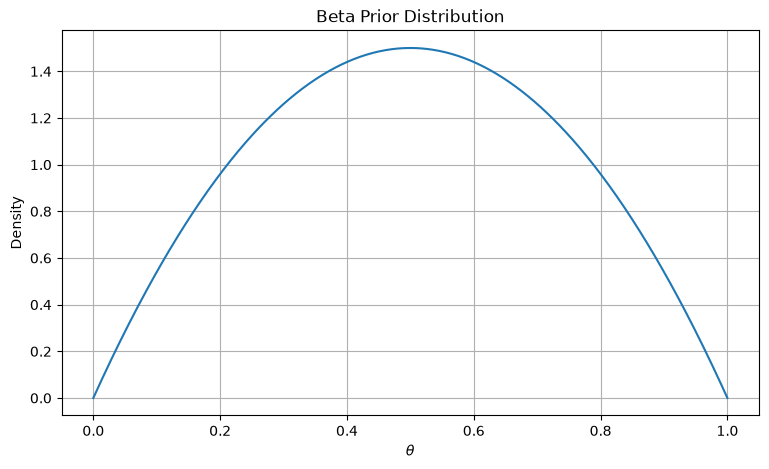

In [3]:
theta = np.linspace(0, 1, 500)

alpha = 2
beta = 2

prior = stats.beta.pdf(theta, alpha, beta)

plt.figure()
plt.plot(theta, prior)
plt.xlabel(r"$\theta$")
plt.ylabel("Density")
plt.title("Beta Prior Distribution")
plt.show()

The prior $\operatorname{Beta}(2,2)$ places greater probability around
$\theta=0.5$ while remaining relatively uncertain.

Now suppose we observe:

- $7$ successes
- $3$ failures

The posterior parameters are:

$$
\alpha_{\text{posterior}}
=
\alpha + x
$$

$$
\beta_{\text{posterior}}
=
\beta + n-x
$$

Therefore:

$$
\alpha_{\text{posterior}} = 2+7=9
$$

and

$$
\beta_{\text{posterior}} = 2+3=5
$$

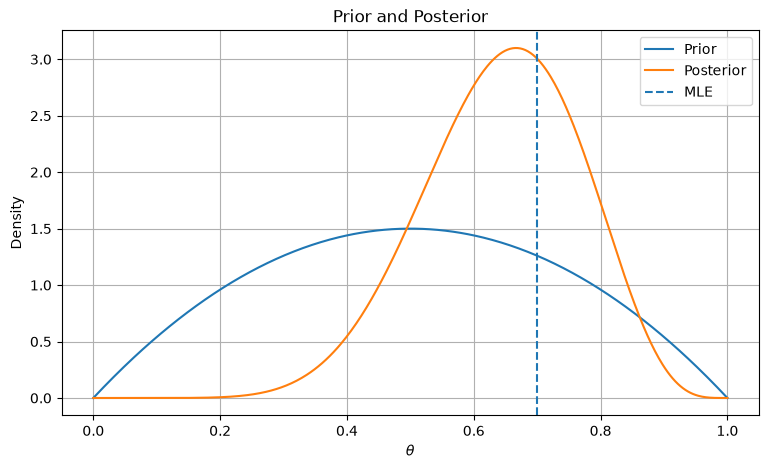

In [4]:
successes = 7
failures = 3

posterior_alpha = alpha + successes
posterior_beta = beta + failures

posterior = stats.beta.pdf(
    theta,
    posterior_alpha,
    posterior_beta
)

plt.figure()
plt.plot(theta, prior, label="Prior")
plt.plot(theta, posterior, label="Posterior")
plt.axvline(
    successes / (successes + failures),
    linestyle="--",
    label="MLE"
)

plt.xlabel(r"$\theta$")
plt.ylabel("Density")
plt.title("Prior and Posterior")
plt.legend()
plt.show()

## 6. Prior, Likelihood, and Posterior

For Bernoulli observations:

$$
x_i \sim \operatorname{Bernoulli}(\theta)
$$

the likelihood is:

$$
p(D\mid\theta)
=
\theta^x(1-\theta)^{n-x}
$$

The prior is:

$$
p(\theta)
=
\operatorname{Beta}(\alpha,\beta)
$$

Therefore:

$$
p(\theta\mid D)
\propto
p(D\mid\theta)p(\theta)
$$

The posterior is again a Beta distribution:

$$
\theta\mid D
\sim
\operatorname{Beta}
(
\alpha+x,
\beta+n-x
)
$$

This property is called **conjugacy**.

A prior is conjugate to a likelihood when the resulting posterior belongs to
the same probability distribution family as the prior.

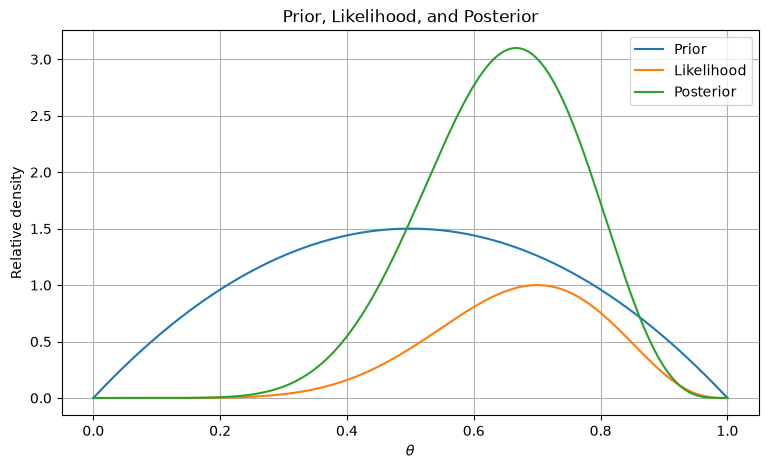

In [5]:
likelihood = (
    theta ** successes
    * (1 - theta) ** failures
)

likelihood = likelihood / np.max(likelihood)

plt.figure()

plt.plot(theta, prior, label="Prior")
plt.plot(theta, likelihood, label="Likelihood")
plt.plot(theta, posterior, label="Posterior")

plt.xlabel(r"$\theta$")
plt.ylabel("Relative density")
plt.title("Prior, Likelihood, and Posterior")
plt.legend()

plt.show()

## 7. MLE vs MAP vs Posterior Mean

Bayesian inference gives us several useful point summaries.

### Maximum Likelihood Estimate

The MLE maximizes the likelihood:

$$
\hat{\theta}_{MLE}
=
\arg\max_\theta p(D\mid\theta)
$$

For Bernoulli data:

$$
\hat{\theta}_{MLE}
=
\frac{x}{n}
$$

### Maximum A Posteriori Estimate

MAP maximizes the posterior:

$$
\hat{\theta}_{MAP}
=
\arg\max_\theta p(\theta\mid D)
$$

Because:

$$
p(\theta\mid D)
\propto
p(D\mid\theta)p(\theta)
$$

MAP incorporates prior information.

### Posterior Mean

Another Bayesian estimate is:

$$
E[\theta\mid D]
$$

For a Beta posterior:

$$
E[\theta\mid D]
=
\frac{\alpha+x}
{\alpha+\beta+n}
$$

In [6]:
n = successes + failures

mle = successes / n

map_estimate = (
    posterior_alpha - 1
) / (
    posterior_alpha + posterior_beta - 2
)

posterior_mean = (
    posterior_alpha
    / (posterior_alpha + posterior_beta)
)

print(f"MLE           = {mle:.4f}")
print(f"MAP           = {map_estimate:.4f}")
print(f"Posterior mean = {posterior_mean:.4f}")

MLE           = 0.7000
MAP           = 0.6667
Posterior mean = 0.6429


## 8. Bayesian Credible Intervals

A major advantage of Bayesian inference is that the posterior gives us a full
distribution over plausible parameter values.

For example, we can calculate a $95\%$ credible interval:

$$
P(a \leq \theta \leq b \mid D)=0.95
$$

For the Beta posterior, this can be obtained directly from its quantiles.

In [7]:
lower, upper = stats.beta.ppf(
    [0.025, 0.975],
    posterior_alpha,
    posterior_beta
)

print(f"95% credible interval: [{lower:.4f}, {upper:.4f}]")

95% credible interval: [0.3857, 0.8614]


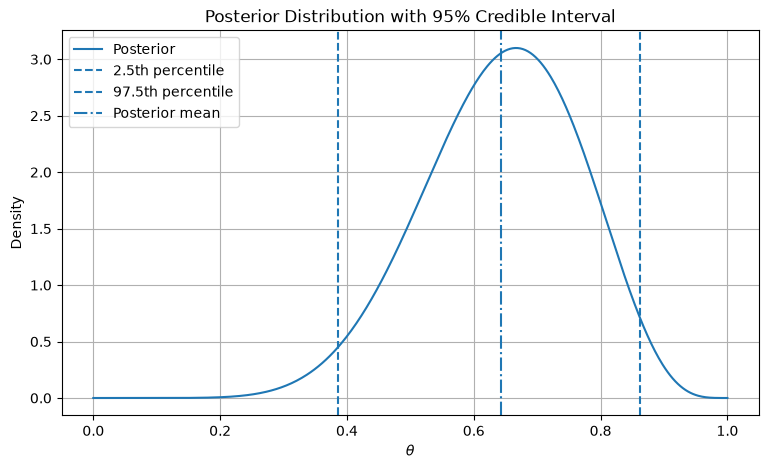

In [8]:
plt.figure()

plt.plot(theta, posterior, label="Posterior")

plt.axvline(
    lower,
    linestyle="--",
    label="2.5th percentile"
)

plt.axvline(
    upper,
    linestyle="--",
    label="97.5th percentile"
)

plt.axvline(
    posterior_mean,
    linestyle="-.",
    label="Posterior mean"
)

plt.xlabel(r"$\theta$")
plt.ylabel("Density")
plt.title("Posterior Distribution with 95% Credible Interval")
plt.legend()

plt.show()

## 9. Bayesian Updating with Increasing Data

One of the most important ideas in Bayesian learning is that posterior uncertainty
usually decreases as more informative observations become available.

We will start with:

$$
\theta \sim \operatorname{Beta}(2,2)
$$

and repeatedly update the posterior using observations generated from:

$$
\theta_{\text{true}} = 0.7
$$

We will observe how the posterior evolves as the amount of data increases.

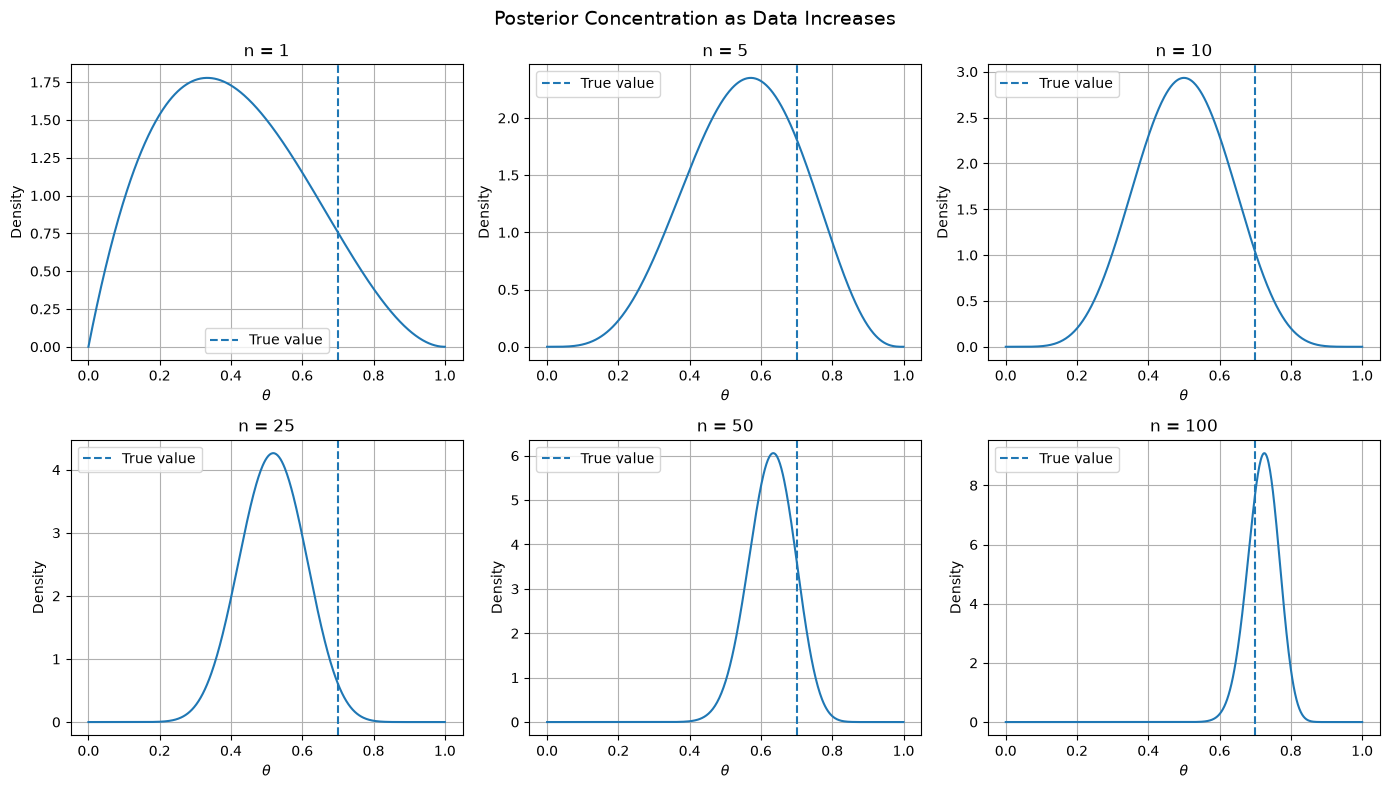

In [9]:
true_theta = 0.7

sample_sizes = [1, 5, 10, 25, 50, 100]

rng = np.random.default_rng(42)

observations = rng.binomial(
    1,
    true_theta,
    size=max(sample_sizes)
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8)
)

for ax, n_obs in zip(axes.ravel(), sample_sizes):

    x = observations[:n_obs].sum()

    a_post = alpha + x
    b_post = beta + n_obs - x

    posterior_density = stats.beta.pdf(
        theta,
        a_post,
        b_post
    )

    ax.plot(theta, posterior_density)
    ax.axvline(
        true_theta,
        linestyle="--",
        label="True value"
    )

    ax.set_title(f"n = {n_obs}")
    ax.set_xlabel(r"$\theta$")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle(
    "Posterior Concentration as Data Increases",
    fontsize=14
)

plt.tight_layout()
plt.show()

As the number of observations increases:

- The posterior becomes more concentrated.
- The posterior mean moves toward the true parameter.
- Uncertainty decreases.
- The influence of the initial prior becomes relatively smaller.

This illustrates an important Bayesian principle:

$$
\text{Posterior}
\propto
\text{Prior}
\times
\text{Likelihood}
$$

With enough informative data, the likelihood can dominate a reasonable prior.

## 10. Posterior Predictive Inference

Bayesian learning is not only about estimating parameters.

Ultimately, we want to make predictions.

For a new observation $y_{\text{new}}$, Bayesian prediction averages over
uncertainty in the parameter:

$$
p(y_{\text{new}}\mid D)
=
\int
p(y_{\text{new}}\mid\theta)
p(\theta\mid D)
\,d\theta
$$

This is called the **posterior predictive distribution**.

For a Bernoulli model:

$$
p(y_{\text{new}}=1\mid D)
=
\int
\theta p(\theta\mid D)
\,d\theta
$$

which is simply:

$$
p(y_{\text{new}}=1\mid D)
=
E[\theta\mid D]
$$

In [11]:
predictive_probability = posterior_mean

print(
    f"Posterior predictive probability of success: "
    f"{predictive_probability:.4f}"
)

Posterior predictive probability of success: 0.6429


## Posterior Predictive Simulation

In [12]:
n_posterior_samples = 10_000

posterior_samples = rng.beta(
    posterior_alpha,
    posterior_beta,
    size=n_posterior_samples
)

predictive_samples = rng.binomial(
    1,
    posterior_samples
)

print(
    f"Estimated predictive probability: "
    f"{predictive_samples.mean():.4f}"
)

Estimated predictive probability: 0.6421


The simulation follows the Bayesian predictive procedure:

1. Sample a parameter from the posterior.
2. Generate a new observation using that parameter.
3. Repeat many times.

This separates two sources of uncertainty:

- **Parameter uncertainty** — uncertainty about $\theta$.
- **Observation uncertainty** — randomness in the new observation given $\theta$.

This distinction becomes especially important in Bayesian regression and
classification.

## Summary

We have established the core Bayesian workflow:

$$
p(\theta)
\rightarrow
p(D\mid\theta)
\rightarrow
p(\theta\mid D)
\rightarrow
p(y_{\text{new}}\mid D)
$$

### Key concepts

**Prior**

$$
p(\theta)
$$

Represents information or assumptions before observing the current data.

**Likelihood**

$$
p(D\mid\theta)
$$

Measures how compatible the observed data are with different parameter values.

**Posterior**

$$
p(\theta\mid D)
\propto
p(D\mid\theta)p(\theta)
$$

Represents updated uncertainty after observing data.

**Posterior predictive**

$$
p(y_{\text{new}}\mid D)
=
\int
p(y_{\text{new}}\mid\theta)
p(\theta\mid D)
\,d\theta
$$

Represents uncertainty about future observations.

### Important connection

MLE uses only the likelihood:

$$
\hat{\theta}_{MLE}
=
\arg\max_\theta p(D\mid\theta)
$$

MAP uses likelihood and prior:

$$
\hat{\theta}_{MAP}
=
\arg\max_\theta
p(D\mid\theta)p(\theta)
$$

Full Bayesian inference goes further by retaining the entire posterior
distribution rather than reducing the result to a single parameter estimate.

## 13. Conjugate Bayesian Models

A prior distribution is **conjugate** to a likelihood when the posterior belongs
to the same distribution family as the prior.

This is useful because the posterior can then often be derived analytically.

The general Bayesian relationship is:

$$
p(\theta \mid D)
\propto
p(D \mid \theta)p(\theta)
$$

Conjugacy gives us a closed-form expression for this posterior.

### Important conjugate pairs

| Likelihood | Prior | Posterior |
|---|---|---|
| Bernoulli | Beta | Beta |
| Binomial | Beta | Beta |
| Multinomial | Dirichlet | Dirichlet |
| Gaussian mean | Gaussian | Gaussian |
| Poisson | Gamma | Gamma |
| Exponential | Gamma | Gamma |

Conjugacy is not a requirement for Bayesian inference. It is primarily a
computational convenience.

When no analytical posterior is available, we can use methods such as:

- MCMC
- Variational inference
- Laplace approximation
- Sequential Monte Carlo

## 14. Beta-Binomial Conjugacy

Consider:

$$
x \sim \operatorname{Binomial}(n,\theta)
$$

with prior:

$$
\theta \sim \operatorname{Beta}(\alpha,\beta)
$$

The likelihood is:

$$
p(x\mid\theta)
\propto
\theta^x(1-\theta)^{n-x}
$$

The Beta prior is:

$$
p(\theta)
\propto
\theta^{\alpha-1}(1-\theta)^{\beta-1}
$$

Therefore:

$$
p(\theta\mid x)
\propto
\theta^{x+\alpha-1}
(1-\theta)^{n-x+\beta-1}
$$

Thus:

$$
\theta\mid x
\sim
\operatorname{Beta}
(\alpha+x,\beta+n-x)
$$

The posterior parameters are simply the prior parameters plus the observed
successes and failures.

In [13]:
alpha_prior = 2
beta_prior = 3

n = 20
x = 14

alpha_post = alpha_prior + x
beta_post = beta_prior + n - x

print("Prior:")
print(f"  alpha = {alpha_prior}")
print(f"  beta  = {beta_prior}")

print("\nPosterior:")
print(f"  alpha = {alpha_post}")
print(f"  beta  = {beta_post}")

Prior:
  alpha = 2
  beta  = 3

Posterior:
  alpha = 16
  beta  = 9


## 15. Dirichlet-Multinomial Model

The Beta distribution generalizes to multiple categories through the
**Dirichlet distribution**.

Suppose:

$$
\boldsymbol{\theta}
=
(\theta_1,\theta_2,\ldots,\theta_K)
$$

where:

$$
\sum_{k=1}^{K}\theta_k=1
$$

We use the prior:

$$
\boldsymbol{\theta}
\sim
\operatorname{Dirichlet}
(\boldsymbol{\alpha})
$$

and observe category counts:

$$
\mathbf{x}
=
(x_1,x_2,\ldots,x_K)
$$

The posterior is:

$$
\boldsymbol{\theta}\mid D
\sim
\operatorname{Dirichlet}
(
\alpha_1+x_1,
\ldots,
\alpha_K+x_K
)
$$

In [14]:
from scipy.stats import dirichlet

alpha = np.array([2.0, 2.0, 2.0])

counts = np.array([8, 5, 2])

posterior_alpha = alpha + counts

print("Prior parameters:", alpha)
print("Observed counts:", counts)
print("Posterior parameters:", posterior_alpha)

Prior parameters: [2. 2. 2.]
Observed counts: [8 5 2]
Posterior parameters: [10.  7.  4.]


## Visualizing a Dirichlet Prior

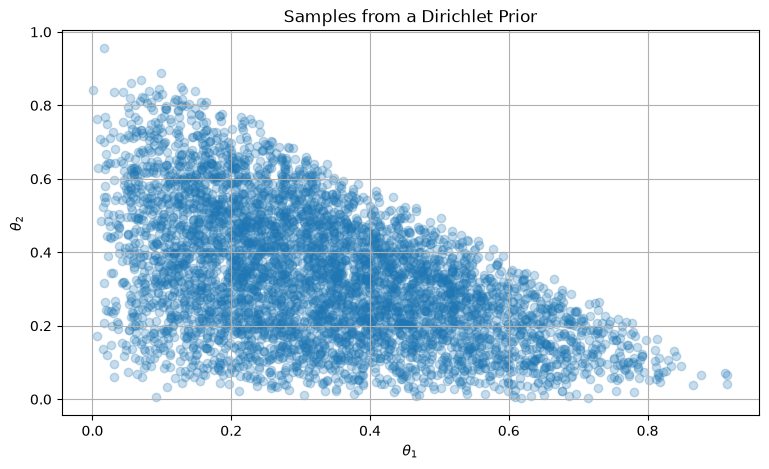

In [15]:
samples = dirichlet.rvs(
    alpha,
    size=5000,
    random_state=42
)

plt.figure()

plt.scatter(
    samples[:, 0],
    samples[:, 1],
    alpha=0.25
)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.title("Samples from a Dirichlet Prior")

plt.show()

Because:

$$
\theta_1+\theta_2+\theta_3=1
$$

only two dimensions are independently represented in this visualization.

The Dirichlet distribution is particularly useful for Bayesian categorical
models, such as:

- Multinomial classification
- Topic models
- Bayesian language models
- Categorical probability estimation

## 17. Gaussian Bayesian Inference

Now consider estimating the mean of a Gaussian distribution.

Assume:

$$
x_i\sim\mathcal{N}(\mu,\sigma^2)
$$

where $\sigma^2$ is known.

We place a Gaussian prior over the unknown mean:

$$
\mu\sim\mathcal{N}(\mu_0,\tau_0^2)
$$

The posterior is also Gaussian:

$$
\mu\mid D
\sim
\mathcal{N}(\mu_n,\tau_n^2)
$$

The posterior precision is:

$$
\frac{1}{\tau_n^2}
=
\frac{1}{\tau_0^2}
+
\frac{n}{\sigma^2}
$$

Therefore:

$$
\tau_n^2
=
\left(
\frac{1}{\tau_0^2}
+
\frac{n}{\sigma^2}
\right)^{-1}
$$

The posterior mean is:

$$
\mu_n
=
\tau_n^2
\left(
\frac{\mu_0}{\tau_0^2}
+
\frac{n\bar{x}}{\sigma^2}
\right)
$$

This equation demonstrates an important Bayesian idea:

> The posterior combines prior information and information from the observed
> data according to their relative precision.

## Implement Gaussian Bayesian Updating

In [16]:
rng = np.random.default_rng(42)

true_mu = 5.0
sigma = 2.0

data = rng.normal(
    true_mu,
    sigma,
    size=30
)

mu_0 = 0.0
tau_0 = 3.0

n = len(data)
x_bar = data.mean()

posterior_variance = 1 / (
    1 / tau_0**2
    + n / sigma**2
)

posterior_mean = posterior_variance * (
    mu_0 / tau_0**2
    + n * x_bar / sigma**2
)

posterior_std = np.sqrt(posterior_variance)

print(f"Sample mean:       {x_bar:.4f}")
print(f"Posterior mean:     {posterior_mean:.4f}")
print(f"Posterior std:      {posterior_std:.4f}")
print(f"True mean:          {true_mu:.4f}")

Sample mean:       5.0336
Posterior mean:     4.9601
Posterior std:      0.3625
True mean:          5.0000


## 20. Bayesian Linear Regression

We now move to one of the most important Bayesian machine-learning models.

Ordinary linear regression assumes:

$$
y=X\beta+\epsilon
$$

with:

$$
\epsilon\sim\mathcal{N}(0,\sigma^2I)
$$

In Bayesian linear regression, the coefficients themselves are uncertain.

We assign a prior:

$$
\beta
\sim
\mathcal{N}(m_0,S_0)
$$

The likelihood is:

$$
p(y\mid X,\beta)
=
\mathcal{N}
(X\beta,\sigma^2I)
$$

Because both the prior and likelihood are Gaussian, the posterior is Gaussian:

$$
\beta\mid X,y
\sim
\mathcal{N}(m_n,S_n)
$$

where:

$$
S_n^{-1}
=
S_0^{-1}
+
\frac{1}{\sigma^2}X^TX
$$

and:

$$
m_n
=
S_n
\left(
S_0^{-1}m_0
+
\frac{1}{\sigma^2}X^Ty
\right)
$$

This is the Bayesian analogue of ordinary linear regression.

## Generate a Regression Dataset

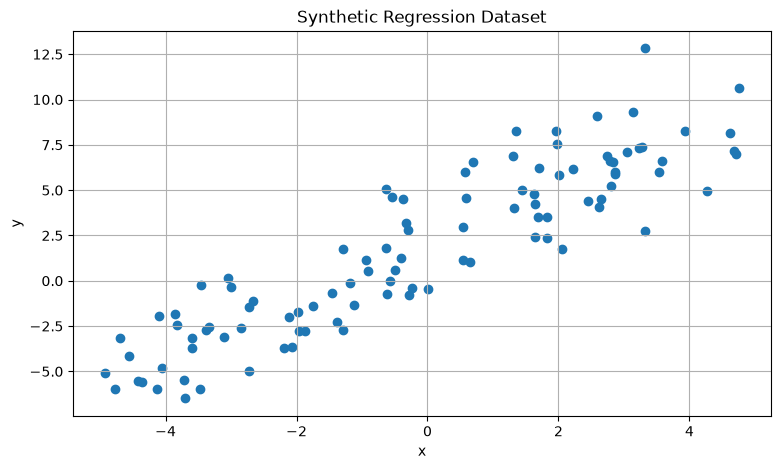

In [17]:
rng = np.random.default_rng(42)

n_samples = 100

X = rng.uniform(
    -5,
    5,
    size=(n_samples, 1)
)

true_intercept = 2.0
true_slope = 1.5
noise_std = 2.0

y = (
    true_intercept
    + true_slope * X[:, 0]
    + rng.normal(0, noise_std, n_samples)
)

plt.figure()

plt.scatter(X[:, 0], y)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic Regression Dataset")

plt.show()

For the regression model:

$$
y=\beta_0+\beta_1x+\epsilon
$$

we represent the design matrix as:

$$
X=
\begin{bmatrix}
1 & x_1\\
1 & x_2\\
\vdots & \vdots\\
1 & x_n
\end{bmatrix}
$$

The first column represents the intercept.

In [18]:
X_design = np.column_stack([
    np.ones(n_samples),
    X[:, 0]
])

print("Design matrix shape:", X_design.shape)
print(X_design[:5])

Design matrix shape: (100, 2)
[[ 1.          2.73956049]
 [ 1.         -0.6112156 ]
 [ 1.          3.5859792 ]
 [ 1.          1.97368029]
 [ 1.         -4.05822652]]


## Compute the Bayesian Posterior

In [19]:
n_features = X_design.shape[1]

m0 = np.zeros(n_features)

S0 = np.eye(n_features) * 10.0

sigma2 = noise_std**2

S0_inv = np.linalg.inv(S0)

Sn = np.linalg.inv(
    S0_inv
    + (X_design.T @ X_design) / sigma2
)

mn = Sn @ (
    S0_inv @ m0
    + (X_design.T @ y) / sigma2
)

print("Posterior mean:")
print(mn)

print("\nPosterior covariance:")
print(Sn)

Posterior mean:
[1.96603763 1.51436774]

Posterior covariance:
[[0.03993503 0.00071352]
 [0.00071352 0.00539376]]


## 24. Compare Bayesian Regression with Ordinary Least Squares

The ordinary least-squares estimator is:

$$
\hat{\beta}_{OLS}
=
(X^TX)^{-1}X^Ty
$$

We can compare it directly with the Bayesian posterior mean.

In [20]:
beta_ols = np.linalg.inv(
    X_design.T @ X_design
) @ (
    X_design.T @ y
)

print("True parameters:")
print([true_intercept, true_slope])

print("\nOLS estimate:")
print(beta_ols)

print("\nBayesian posterior mean:")
print(mn)   

True parameters:
[2.0, 1.5]

OLS estimate:
[1.97402904 1.51532592]

Bayesian posterior mean:
[1.96603763 1.51436774]


## 25. Posterior Parameter Uncertainty

The Bayesian model gives us a distribution over regression coefficients:

$$
\beta\mid D
\sim
\mathcal{N}(m_n,S_n)
$$

Therefore, instead of obtaining one regression line, we can sample many
plausible regression lines from the posterior.

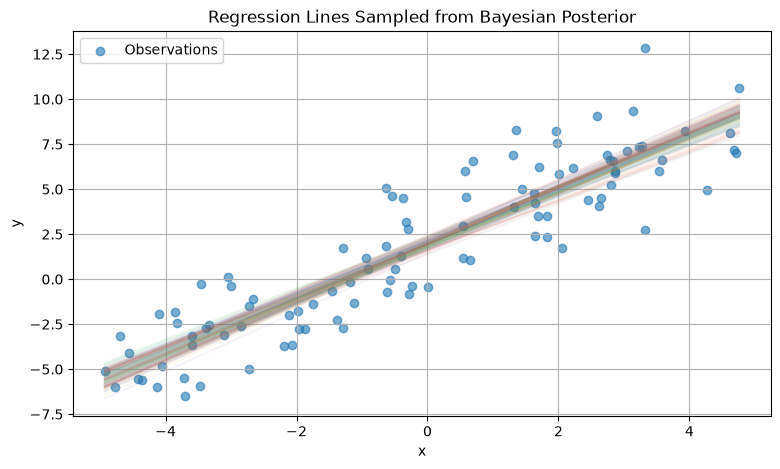

In [21]:
posterior_beta_samples = rng.multivariate_normal(
    mean=mn,
    cov=Sn,
    size=300
)

x_grid = np.linspace(
    X[:, 0].min(),
    X[:, 0].max(),
    200
)

plt.figure()

for beta in posterior_beta_samples[:100]:
    y_sample = beta[0] + beta[1] * x_grid
    plt.plot(
        x_grid,
        y_sample,
        alpha=0.08
    )

plt.scatter(
    X[:, 0],
    y,
    alpha=0.6,
    label="Observations"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Regression Lines Sampled from Bayesian Posterior")
plt.legend()

plt.show()

## Bayesian Regression Mean and Credible Band

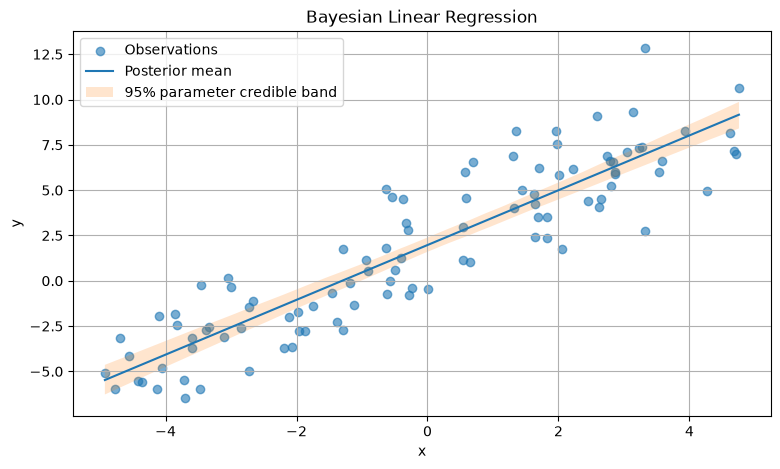

In [22]:
predicted_lines = (
    posterior_beta_samples[:, 0, None]
    + posterior_beta_samples[:, 1, None] * x_grid
)

lower_band = np.percentile(
    predicted_lines,
    2.5,
    axis=0
)

upper_band = np.percentile(
    predicted_lines,
    97.5,
    axis=0
)

mean_line = predicted_lines.mean(axis=0)

plt.figure()

plt.scatter(
    X[:, 0],
    y,
    alpha=0.6,
    label="Observations"
)

plt.plot(
    x_grid,
    mean_line,
    label="Posterior mean"
)

plt.fill_between(
    x_grid,
    lower_band,
    upper_band,
    alpha=0.2,
    label="95% parameter credible band"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Bayesian Linear Regression")
plt.legend()

plt.show()

## Parameter Posterior Distributions

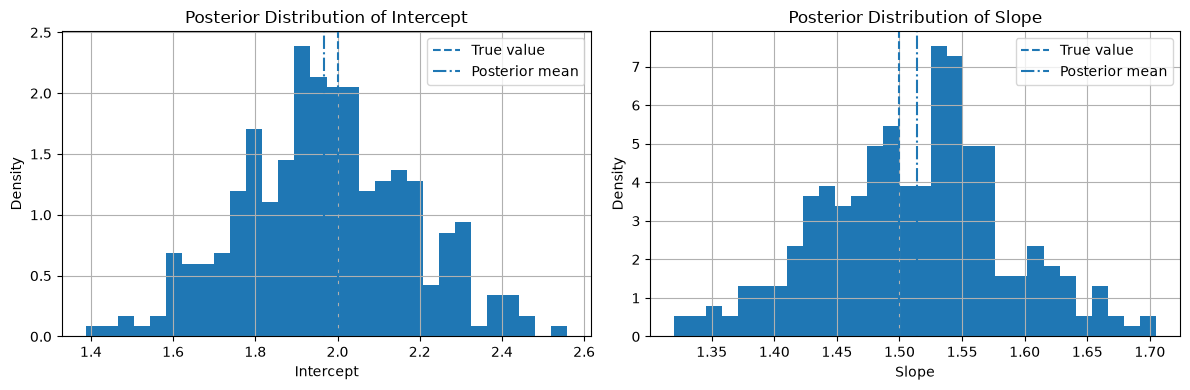

In [23]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

parameter_names = [
    "Intercept",
    "Slope"
]

for i, ax in enumerate(axes):

    ax.hist(
        posterior_beta_samples[:, i],
        bins=30,
        density=True
    )

    ax.axvline(
        [true_intercept, true_slope][i],
        linestyle="--",
        label="True value"
    )

    ax.axvline(
        mn[i],
        linestyle="-.",
        label="Posterior mean"
    )

    ax.set_xlabel(parameter_names[i])
    ax.set_ylabel("Density")
    ax.set_title(
        f"Posterior Distribution of {parameter_names[i]}"
    )
    ax.legend()

plt.tight_layout()
plt.show()

## 28. Bayesian Regression and Regularization

There is an important connection between Bayesian priors and regularization.

Suppose:

$$
\beta\sim\mathcal{N}(0,\tau^2I)
$$

Then:

$$
\log p(\beta)
\propto
-\frac{1}{2\tau^2}\|\beta\|_2^2
$$

MAP estimation therefore produces an optimization objective containing an
$L_2$ penalty.

This creates a direct connection:

$$
\boxed{
\text{Gaussian prior}
\Longleftrightarrow
L_2\text{ regularization}
}
$$

Consequently, Ridge regression can be interpreted as a MAP estimator under
a Gaussian prior.

This is one of the most useful connections between Bayesian statistics and
machine learning.

## Ridge vs Bayesian MAP — Practical Demonstration

In [24]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(
    X_design,
    y
)

print("Ridge coefficients:")
print(ridge.coef_)

print("\nRidge intercept:")
print(ridge.intercept_)

Ridge coefficients:
[0.         1.51328422]

Ridge intercept:
1.973757872714467


For this simple two-parameter example, the precise correspondence between the
Ridge penalty and the Bayesian prior depends on the assumed noise variance and
parameterization.

The important conceptual relationship is:

$$
\text{Regularization}
=
\text{MAP estimation with an appropriate prior}
$$

Bayesian inference goes beyond MAP because it retains uncertainty over the
parameters instead of keeping only the most probable parameter value.

## Summary

We have now moved from basic Bayesian updating to Bayesian machine learning.

### Conjugate inference

Conjugacy allows analytical posterior distributions:

$$
p(\theta\mid D)
\in
\text{same family as }p(\theta)
$$

### Gaussian inference

For a Gaussian likelihood with a Gaussian prior on the mean:

$$
\mu\mid D
\sim
\mathcal{N}(\mu_n,\tau_n^2)
$$

### Bayesian linear regression

The coefficients have a posterior distribution:

$$
\beta\mid D
\sim
\mathcal{N}(m_n,S_n)
$$

rather than a single fixed estimate.

### Important connection

A Gaussian prior on regression coefficients leads to $L_2$ regularization
under MAP estimation:

$$
\text{Gaussian prior}
\Longleftrightarrow
\text{Ridge-style regularization}
$$

### Main conceptual difference

Ordinary regression asks:

> What is the best parameter estimate?

Bayesian regression asks:

> Given the data and our prior assumptions, what values of the parameters
> remain plausible, and how uncertain are we about them?

## 31. Bayesian Logistic Regression

Linear regression has a convenient Gaussian likelihood and Gaussian posterior
under a Gaussian prior.

Classification is different.

For binary classification:

$$
y_i \sim \operatorname{Bernoulli}(p_i)
$$

where:

$$
p_i = \sigma(x_i^T\beta)
$$

and the sigmoid function is:

$$
\sigma(z)
=
\frac{1}{1+e^{-z}}
$$

Therefore:

$$
p(y_i=1\mid x_i,\beta)
=
\sigma(x_i^T\beta)
$$

The likelihood for the complete dataset is:

$$
p(y\mid X,\beta)
=
\prod_{i=1}^{n}
p_i^{y_i}
(1-p_i)^{1-y_i}
$$

Unlike Bayesian linear regression, combining this likelihood with a Gaussian
prior does not produce a standard closed-form posterior.

This is an example of **non-conjugate Bayesian inference**.

## Generate a Classification Dataset

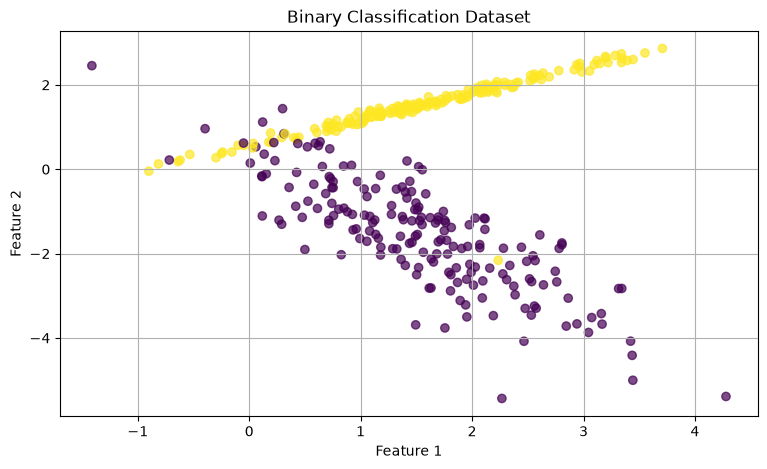

In [25]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

plt.figure()

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    alpha=0.7
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")

plt.show()

For the logistic regression model:

$$
p(y_i=1\mid x_i,\beta)
=
\sigma(\beta_0+\beta_1x_{i1}+\beta_2x_{i2})
$$

we augment the feature matrix with a column of ones.

In [26]:
X_train_design = np.column_stack([
    np.ones(len(X_train)),
    X_train
])

X_test_design = np.column_stack([
    np.ones(len(X_test)),
    X_test
])

n_features = X_train_design.shape[1]

print("Training design matrix:", X_train_design.shape)
print("Test design matrix:", X_test_design.shape)

Training design matrix: (375, 3)
Test design matrix: (125, 3)


## 34. Logistic Regression Log-Likelihood

The Bernoulli likelihood is:

$$
p(y\mid X,\beta)
=
\prod_{i=1}^{n}
p_i^{y_i}
(1-p_i)^{1-y_i}
$$

Working with the logarithm gives:

$$
\log p(y\mid X,\beta)
=
\sum_{i=1}^{n}
\left[
y_i\log p_i
+
(1-y_i)\log(1-p_i)
\right]
$$

Logarithms convert products into sums and make numerical computation more
stable.

In [27]:
def log_likelihood_logistic(beta, X, y):
    logits = X @ beta
    probabilities = expit(logits)

    probabilities = np.clip(
        probabilities,
        1e-12,
        1 - 1e-12
    )

    return np.sum(
        y * np.log(probabilities)
        + (1 - y) * np.log(1 - probabilities)
    )

## 35. Gaussian Prior

We place a Gaussian prior on the regression coefficients:

$$
\beta
\sim
\mathcal{N}(0,\tau^2I)
$$

Ignoring constants, its log-density is:

$$
\log p(\beta)
\propto
-\frac{1}{2\tau^2}\beta^T\beta
$$

Therefore, the log-posterior is:

$$
\log p(\beta\mid X,y)
=
\log p(y\mid X,\beta)
+
\log p(\beta)
+
C
$$

where $C$ contains terms that do not depend on $\beta$.

In [28]:
prior_std = 5.0

def log_prior(beta, prior_std=5.0):
    return -0.5 * np.sum(
        (beta / prior_std) ** 2
    )

def log_posterior(beta, X, y, prior_std=5.0):
    return (
        log_likelihood_logistic(beta, X, y)
        + log_prior(beta, prior_std)
    )

## 36. MAP Estimation

The Maximum A Posteriori estimator is:

$$
\hat{\beta}_{MAP}
=
\arg\max_\beta
p(\beta\mid X,y)
$$

Equivalently:

$$
\hat{\beta}_{MAP}
=
\arg\max_\beta
\left[
\log p(y\mid X,\beta)
+
\log p(\beta)
\right]
$$

It is usually easier to minimize the negative log-posterior:

$$
\hat{\beta}_{MAP}
=
\arg\min_\beta
-\log p(\beta\mid X,y)
$$

In [29]:
from scipy.optimize import minimize

initial_beta = np.zeros(n_features)

result = minimize(
    lambda beta: -log_posterior(
        beta,
        X_train_design,
        y_train,
        prior_std
    ),
    initial_beta,
    method="BFGS"
)

beta_map = result.x

print("MAP estimate:")
print(beta_map)

print("\nOptimization successful:", result.success)
print("Final objective:", result.fun)

MAP estimate:
[-1.32380922  0.21103277  3.06849946]

Optimization successful: True
Final objective: 58.9904482380872


The MLE ignores the prior:

$$
\hat{\beta}_{MLE}
=
\arg\max_\beta
\log p(y\mid X,\beta)
$$

The MAP estimate incorporates the prior:

$$
\hat{\beta}_{MAP}
=
\arg\max_\beta
\left[
\log p(y\mid X,\beta)
+
\log p(\beta)
\right]
$$

For a Gaussian prior, the MAP objective contains an $L_2$ penalty.

Thus:

$$
\boxed{
\text{Gaussian prior}
\Longleftrightarrow
L_2\text{ regularization}
}
$$

In [30]:
mle_result = minimize(
    lambda beta: -log_likelihood_logistic(
        beta,
        X_train_design,
        y_train
    ),
    initial_beta,
    method="BFGS"
)

beta_mle = mle_result.x

print("MLE coefficients:")
print(beta_mle)

print("\nMAP coefficients:")
print(beta_map)

print("\nDifference:")
print(beta_mle - beta_map)

MLE coefficients:
[-1.33918893  0.21206084  3.08972987]

MAP coefficients:
[-1.32380922  0.21103277  3.06849946]

Difference:
[-0.01537971  0.00102807  0.02123041]


## Visualize the MAP Decision Boundary

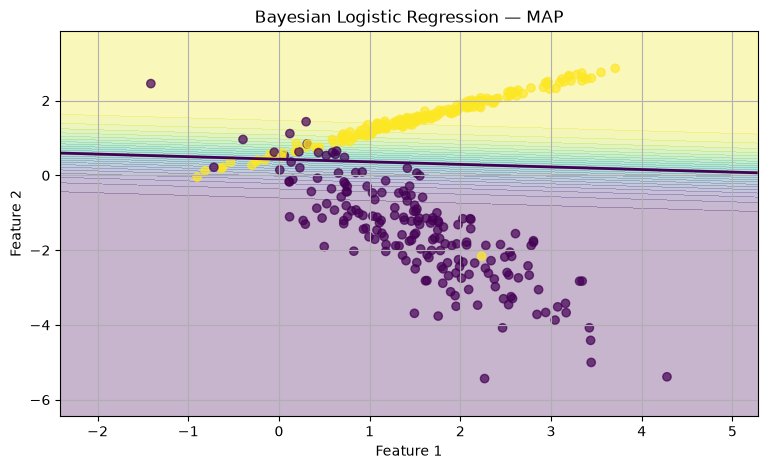

In [31]:
def plot_decision_boundary(
    X,
    y,
    beta,
    title
):
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, 300),
        np.linspace(x2_min, x2_max, 300)
    )

    grid = np.column_stack([
        np.ones(xx1.size),
        xx1.ravel(),
        xx2.ravel()
    ])

    probabilities = expit(grid @ beta)

    probabilities = probabilities.reshape(
        xx1.shape
    )

    plt.figure()

    plt.contourf(
        xx1,
        xx2,
        probabilities,
        levels=30,
        alpha=0.3
    )

    plt.contour(
        xx1,
        xx2,
        probabilities,
        levels=[0.5],
        linewidths=2
    )

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        alpha=0.7
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)

    plt.show()


plot_decision_boundary(
    X_train,
    y_train,
    beta_map,
    "Bayesian Logistic Regression — MAP"
)

## 39. Why We Need Approximate Inference

For Bayesian logistic regression:

$$
p(\beta\mid X,y)
\propto
p(y\mid X,\beta)p(\beta)
$$

The posterior does not have a convenient analytical form.

Therefore, we cannot simply write down:

$$
\beta\mid X,y
\sim
\text{known distribution}
$$

Instead, we need an approximation.

Common approaches include:

1. **Laplace approximation**
2. **Markov Chain Monte Carlo (MCMC)**
3. **Variational inference**
4. **Sequential Monte Carlo**

We will first study Laplace approximation and then implement MCMC.

## 40. Laplace Approximation

The Laplace approximation approximates a complicated posterior with a Gaussian
distribution centered around its mode.

Let:

$$
\hat{\beta}_{MAP}
$$

be the posterior mode.

We approximate:

$$
p(\beta\mid D)
\approx
\mathcal{N}
(\hat{\beta}_{MAP},\Sigma)
$$

where:

$$
\Sigma
=
H^{-1}
$$

and $H$ is the negative Hessian of the log-posterior evaluated at the MAP
estimate.

The intuition is:

> Near its maximum, a sufficiently smooth log-posterior can be approximated
> by a quadratic function.

A Gaussian distribution has a quadratic log-density, making it a natural
approximation.

## Numerical Hessian

In [32]:
def numerical_hessian(
    function,
    x,
    epsilon=1e-5
):
    n = len(x)
    H = np.zeros((n, n))

    for i in range(n):
        for j in range(n):

            ei = np.zeros(n)
            ej = np.zeros(n)

            ei[i] = epsilon
            ej[j] = epsilon

            H[i, j] = (
                function(x + ei + ej)
                - function(x + ei - ej)
                - function(x - ei + ej)
                + function(x - ei - ej)
            ) / (4 * epsilon**2)

    return H

## Construct the Laplace Approximation

In [33]:
negative_log_posterior = lambda beta: -log_posterior(
    beta,
    X_train_design,
    y_train,
    prior_std
)

H = numerical_hessian(
    negative_log_posterior,
    beta_map
)

laplace_covariance = np.linalg.inv(H)

laplace_std = np.sqrt(
    np.diag(laplace_covariance)
)

print("MAP estimate:")
print(beta_map)

print("\nApproximate posterior standard deviations:")
print(laplace_std)

print("\nLaplace covariance matrix:")
print(laplace_covariance)

MAP estimate:
[-1.32380922  0.21103277  3.06849946]

Approximate posterior standard deviations:
[0.36166647 0.36786276 0.38058224]

Laplace covariance matrix:
[[ 0.13080263 -0.06492296 -0.06222662]
 [-0.06492296  0.13532301 -0.02875879]
 [-0.06222662 -0.02875879  0.14484284]]


## Draw Samples from the Laplace Approximation

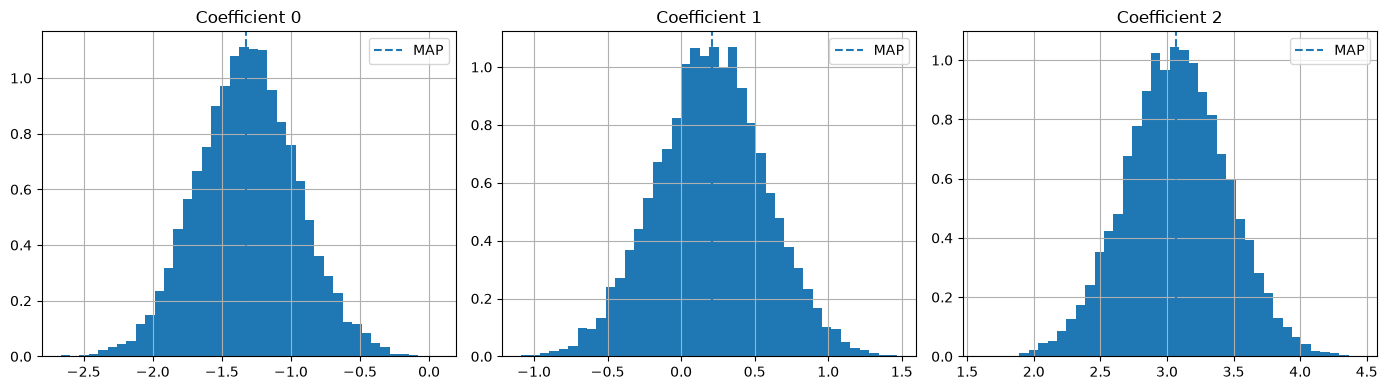

In [34]:
laplace_samples = rng.multivariate_normal(
    mean=beta_map,
    cov=laplace_covariance,
    size=10_000
)

fig, axes = plt.subplots(
    1,
    n_features,
    figsize=(14, 4)
)

for i, ax in enumerate(axes):

    ax.hist(
        laplace_samples[:, i],
        bins=40,
        density=True
    )

    ax.axvline(
        beta_map[i],
        linestyle="--",
        label="MAP"
    )

    ax.set_title(
        f"Coefficient {i}"
    )

    ax.legend()

plt.tight_layout()
plt.show()

## 44. Markov Chain Monte Carlo

MCMC provides a fundamentally different strategy.

Instead of trying to explicitly calculate the posterior density, MCMC generates
samples whose long-run distribution approaches the target posterior.

Suppose our target distribution is:

$$
p(\beta\mid D)
$$

MCMC constructs a Markov chain:

$$
\beta^{(1)}
\rightarrow
\beta^{(2)}
\rightarrow
\beta^{(3)}
\rightarrow
\cdots
$$

After the chain has converged, the samples approximately follow:

$$
\beta^{(t)}
\sim
p(\beta\mid D)
$$

We can then estimate quantities of interest using the samples.

For example:

$$
E[\beta\mid D]
\approx
\frac{1}{N}
\sum_{i=1}^{N}\beta^{(i)}
$$

and posterior probabilities can be estimated from the proportion of samples
satisfying a condition.

## 45. Metropolis-Hastings

The Metropolis-Hastings algorithm constructs a Markov chain using proposed
parameter values.

At iteration $t$:

1. Start with the current parameter $\beta^{(t)}$.
2. Generate a proposal $\beta'$.
3. Calculate the acceptance probability.
4. Accept or reject the proposal.
5. Repeat.

For a symmetric proposal distribution:

$$
q(\beta'\mid\beta)
=
q(\beta\mid\beta')
$$

the acceptance probability is:

$$
\alpha
=
\min
\left(
1,
\frac{
p(\beta'\mid D)
}{
p(\beta\mid D)
}
\right)
$$

Since the posterior is only known up to proportionality, we do not need to
calculate its normalization constant.

## Metropolis-Hastings from Scratch

In [35]:
def metropolis_hastings(
    log_target,
    initial_state,
    n_samples,
    proposal_std,
    random_state=None
):
    rng = np.random.default_rng(random_state)

    initial_state = np.asarray(
        initial_state,
        dtype=float
    )

    current = initial_state.copy()
    current_log_prob = log_target(current)

    samples = np.zeros(
        (n_samples, len(current))
    )

    accepted = 0

    for i in range(n_samples):

        proposal = (
            current
            + rng.normal(
                0,
                proposal_std,
                size=len(current)
            )
        )

        proposal_log_prob = log_target(
            proposal
        )

        log_acceptance_ratio = (
            proposal_log_prob
            - current_log_prob
        )

        if (
            np.log(rng.uniform())
            < log_acceptance_ratio
        ):
            current = proposal
            current_log_prob = proposal_log_prob
            accepted += 1

        samples[i] = current

    acceptance_rate = accepted / n_samples

    return samples, acceptance_rate

## Run MCMC

In [36]:
mcmc_samples, acceptance_rate = metropolis_hastings(
    log_target=lambda beta: log_posterior(
        beta,
        X_train_design,
        y_train,
        prior_std
    ),
    initial_state=np.zeros(n_features),
    n_samples=20_000,
    proposal_std=0.15,
    random_state=42
)

print(
    f"Acceptance rate: {acceptance_rate:.3f}"
)

Acceptance rate: 0.674


## 48. Burn-in

The initial part of an MCMC chain can depend strongly on the starting value.

These early samples may not yet represent the target posterior well.

We therefore discard an initial **burn-in** period.

If:

$$
\{\beta^{(1)},\ldots,\beta^{(T)}\}
$$

is the complete chain, we may retain:

$$
\{\beta^{(B+1)},\ldots,\beta^{(T)}\}
$$

where $B$ is the burn-in length.

Burn-in does not automatically guarantee convergence. It is only one part of
MCMC diagnostics.

In [37]:
burn_in = 5_000

posterior_mcmc_samples = mcmc_samples[
    burn_in:
]

print(
    "Total samples:",
    len(mcmc_samples)
)

print(
    "Post burn-in samples:",
    len(posterior_mcmc_samples)
)

Total samples: 20000
Post burn-in samples: 15000


## MCMC Trace Plots

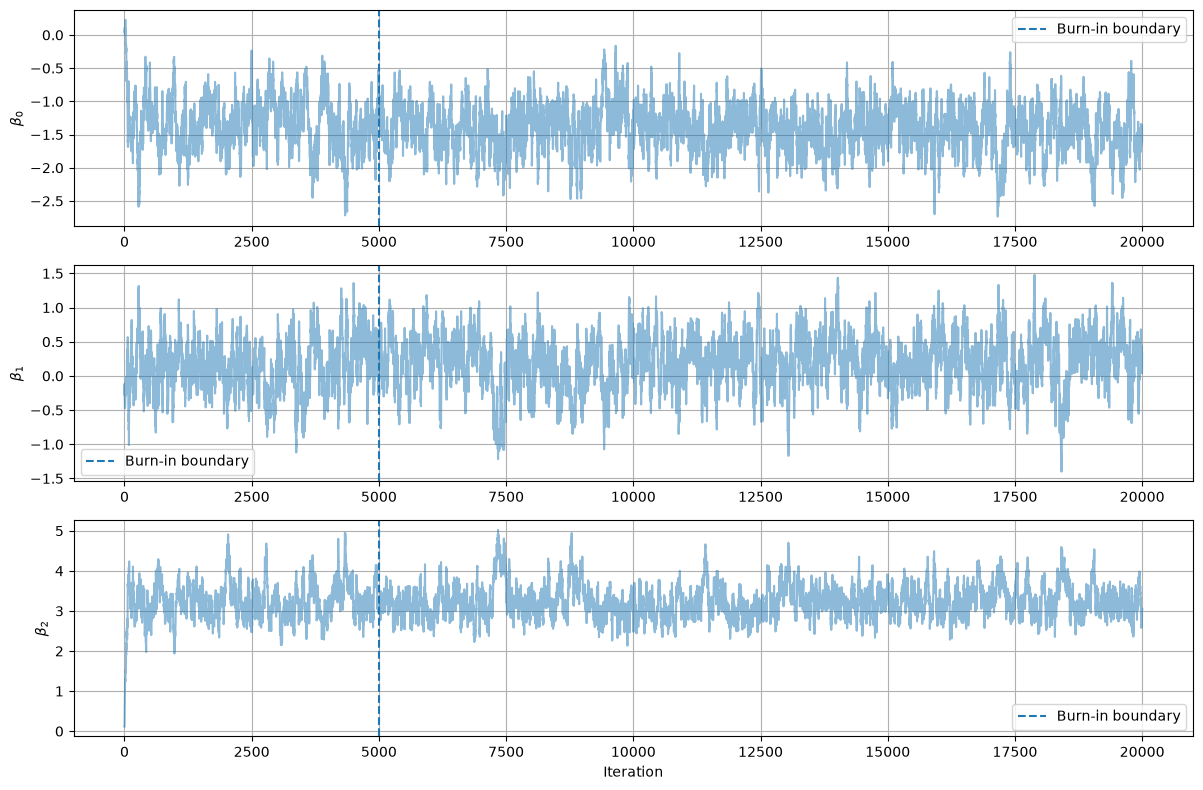

In [38]:
fig, axes = plt.subplots(
    n_features,
    1,
    figsize=(12, 8)
)

if n_features == 1:
    axes = [axes]

for i, ax in enumerate(axes):

    ax.plot(
        mcmc_samples[:, i],
        alpha=0.5
    )

    ax.axvline(
        burn_in,
        linestyle="--",
        label="Burn-in boundary"
    )

    ax.set_ylabel(
        f"$\\beta_{i}$"
    )

    ax.legend()

axes[-1].set_xlabel("Iteration")

plt.tight_layout()
plt.show()

## MCMC Posterior Distributions

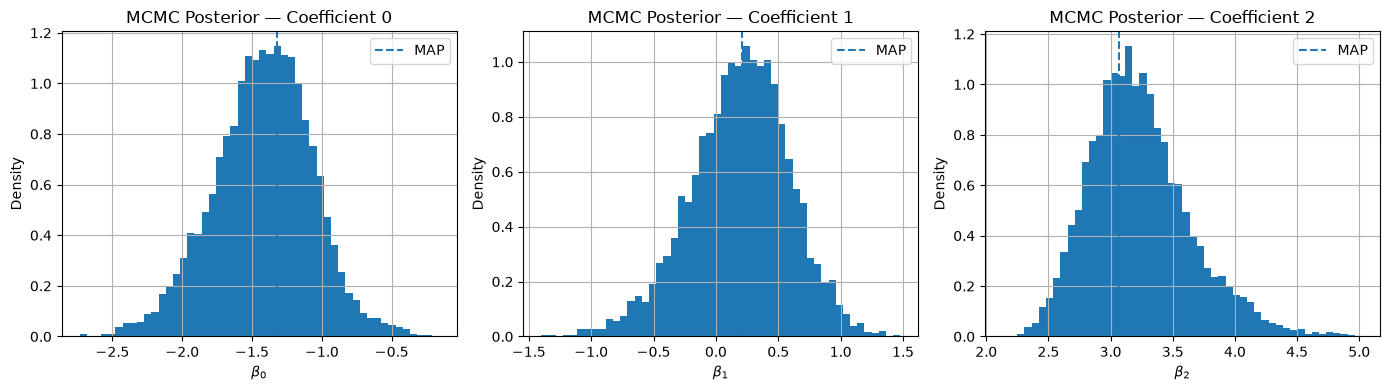

In [39]:
fig, axes = plt.subplots(
    1,
    n_features,
    figsize=(14, 4)
)

for i, ax in enumerate(axes):

    ax.hist(
        posterior_mcmc_samples[:, i],
        bins=50,
        density=True
    )

    ax.axvline(
        beta_map[i],
        linestyle="--",
        label="MAP"
    )

    ax.set_xlabel(
        f"$\\beta_{i}$"
    )

    ax.set_ylabel("Density")

    ax.set_title(
        f"MCMC Posterior — Coefficient {i}"
    )

    ax.legend()

plt.tight_layout()
plt.show()

## 51. Comparing Approximate Bayesian Inference Methods

We now have three representations of the posterior:

### MAP

A single point:

$$
\hat{\beta}_{MAP}
$$

### Laplace approximation

A Gaussian approximation:

$$
p(\beta\mid D)
\approx
\mathcal{N}
(\hat{\beta}_{MAP},H^{-1})
$$

### MCMC

A collection of samples:

$$
\beta^{(1)},\ldots,\beta^{(N)}
$$

which approximately follow:

$$
p(\beta\mid D)
$$

MCMC is more flexible because it does not require the posterior to be
approximately Gaussian, but it is generally computationally more expensive.

In [40]:
mcmc_mean = posterior_mcmc_samples.mean(axis=0)
mcmc_std = posterior_mcmc_samples.std(axis=0)

comparison = pd.DataFrame({
    "MAP": beta_map,
    "Laplace Mean": beta_map,
    "Laplace Std": laplace_std,
    "MCMC Mean": mcmc_mean,
    "MCMC Std": mcmc_std
})

comparison.index = [
    "Intercept",
    "Feature 1",
    "Feature 2"
]

comparison

,MAP,Laplace Mean,Laplace Std,MCMC Mean,MCMC Std
Intercept,-1.323809,-1.323809,0.361666,-1.420090,0.352741
Feature 1,0.211033,0.211033,0.367863,0.191428,0.398296
Feature 2,3.068499,3.068499,0.380582,3.233515,0.407056


## MCMC Credible Intervals

In [41]:
mcmc_intervals = np.percentile(
    posterior_mcmc_samples,
    [2.5, 97.5],
    axis=0
)

mcmc_summary = pd.DataFrame({
    "Posterior Mean": mcmc_mean,
    "Posterior Std": mcmc_std,
    "Lower 95%": mcmc_intervals[0],
    "Upper 95%": mcmc_intervals[1]
})

mcmc_summary.index = [
    "Intercept",
    "Feature 1",
    "Feature 2"
]

mcmc_summary

,Posterior Mean,Posterior Std,Lower 95%,Upper 95%
Intercept,-1.420090,0.352741,-2.146430,-0.749024
Feature 1,0.191428,0.398296,-0.658713,0.934678
Feature 2,3.233515,0.407056,2.557090,4.160419


## 53. Posterior Predictive Classification

We can use every posterior sample to make predictions.

For a parameter sample $\beta^{(s)}$:

$$
p^{(s)}(y=1\mid x)
=
\sigma(x^T\beta^{(s)})
$$

The posterior predictive probability is approximated by:

$$
p(y=1\mid x,D)
\approx
\frac{1}{S}
\sum_{s=1}^{S}
p^{(s)}(y=1\mid x)
$$

This averages predictions over parameter uncertainty.

In [42]:
test_probabilities = np.zeros(
    len(X_test_design)
)

for beta in posterior_mcmc_samples[::10]:

    test_probabilities += expit(
        X_test_design @ beta
    )

test_probabilities /= len(
    posterior_mcmc_samples[::10]
)

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

print(
    "First 10 predictive probabilities:"
)

print(test_probabilities[:10])

First 10 predictive probabilities:
[9.97295222e-01 5.05541332e-02 9.83313738e-01 9.90817706e-01
 2.92360972e-02 9.95631902e-01 8.49318058e-01 1.64499734e-04
 1.95763701e-04 2.14976204e-02]


## Evaluate the Bayesian Classifier

In [43]:
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    roc_auc_score
)

accuracy = accuracy_score(
    y_test,
    test_predictions
)

logloss = log_loss(
    y_test,
    test_probabilities
)

auc = roc_auc_score(
    y_test,
    test_probabilities
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Log Loss : {logloss:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

Accuracy : 0.9760
Log Loss : 0.0898
ROC-AUC  : 0.9987


## 55. Predictive Uncertainty

A Bayesian classifier can provide more than a hard class label.

For each test observation we can examine the distribution of predicted
probabilities across posterior samples.

For observation $x$:

$$
p^{(s)}
=
\sigma(x^T\beta^{(s)})
$$

The spread of these values represents uncertainty caused by uncertainty in
the model parameters.

Observations with predictive probabilities close to $0.5$ are difficult to
classify.

Observations with probabilities close to $0$ or $1$ generally have more
confident predictions.

However, predictive uncertainty and parameter uncertainty are not identical;
future observation noise can introduce an additional source of uncertainty.

In [44]:
sampled_probabilities = np.array([
    expit(X_test_design @ beta)
    for beta in posterior_mcmc_samples[::20]
])

predictive_mean = sampled_probabilities.mean(
    axis=0
)

predictive_lower = np.percentile(
    sampled_probabilities,
    2.5,
    axis=0
)

predictive_upper = np.percentile(
    sampled_probabilities,
    97.5,
    axis=0
)

uncertainty_df = pd.DataFrame({
    "True Label": y_test,
    "Predictive Mean": predictive_mean,
    "Lower 95%": predictive_lower,
    "Upper 95%": predictive_upper
})

uncertainty_df.head(10)

,True Label,Predictive Mean,Lower 95%,Upper 95%
0,1,0.997221,9.905038e-01,0.999692
1,0,0.050059,8.847185e-03,0.108970
2,1,0.982999,9.555798e-01,0.996273
3,1,0.990619,9.728249e-01,0.998354
4,0,0.028829,1.598272e-03,0.092654
5,1,0.995522,9.855692e-01,0.999406
6,1,0.848377,7.736065e-01,0.913090
7,0,0.000164,4.649716e-07,0.000915
8,0,0.000195,1.298953e-06,0.000948
9,0,0.021382,4.188116e-03,0.047959


## 57. Key Lessons

Bayesian logistic regression demonstrates why Bayesian inference becomes
computationally interesting in realistic machine-learning models.

### 1. The posterior is not always analytically available

For logistic regression:

$$
p(\beta\mid X,y)
\propto
p(y\mid X,\beta)p(\beta)
$$

does not have a convenient standard closed form.

### 2. MAP is optimization

$$
\hat{\beta}_{MAP}
=
\arg\max_\beta
p(\beta\mid X,y)
$$

It gives one parameter estimate.

### 3. Laplace approximation approximates the posterior

$$
p(\beta\mid D)
\approx
\mathcal{N}
(\hat{\beta}_{MAP},H^{-1})
$$

### 4. MCMC samples from the posterior

MCMC attempts to generate:

$$
\beta^{(1)},\ldots,\beta^{(N)}
\sim
p(\beta\mid D)
$$

### 5. Bayesian prediction averages over parameter uncertainty

$$
p(y_{\text{new}}\mid x,D)
=
\int
p(y_{\text{new}}\mid x,\beta)
p(\beta\mid D)
\,d\beta
$$

This is fundamentally different from simply plugging a single point estimate
into the predictive model.

## 58. MCMC Diagnostics

Obtaining MCMC samples is not enough.

We must determine whether the Markov chain has adequately explored the
posterior distribution.

Important diagnostics include:

- Trace plots
- Acceptance rate
- Autocorrelation
- Effective Sample Size (ESS)
- Potential Scale Reduction Factor ($\hat{R}$)
- Divergences for advanced samplers

No single diagnostic proves convergence.

A reliable Bayesian workflow combines several diagnostics.

## 59. Autocorrelation

MCMC samples are generally dependent.

For a stationary sequence $\{X_t\}$, the lag-$k$ autocorrelation is:

$$
\rho_k
=
\operatorname{Corr}(X_t,X_{t+k})
$$

If autocorrelation is high, consecutive samples contain less independent
information.

This means that:

$$
N_{\text{MCMC samples}}
\neq
N_{\text{independent samples}}
$$

in general.

Lower autocorrelation usually means more efficient exploration of the
posterior.

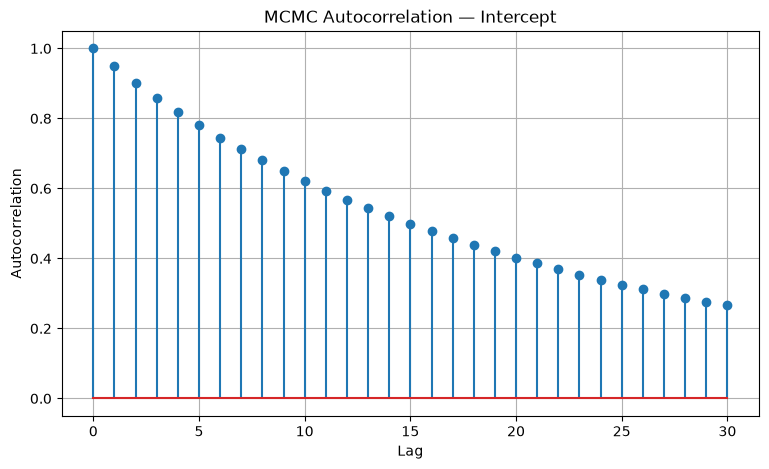

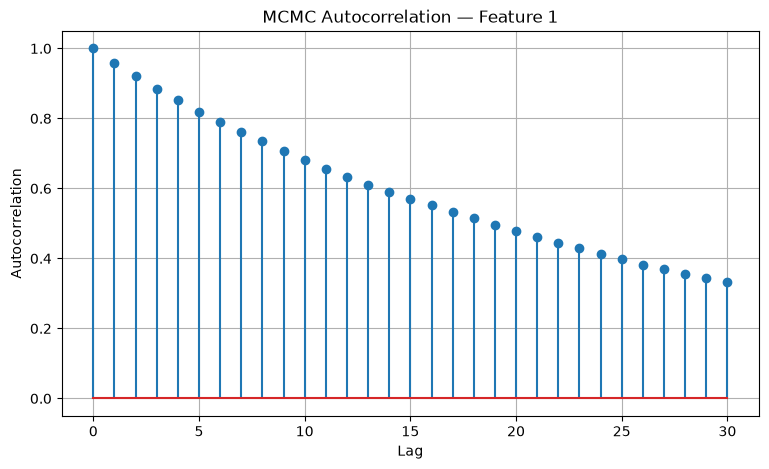

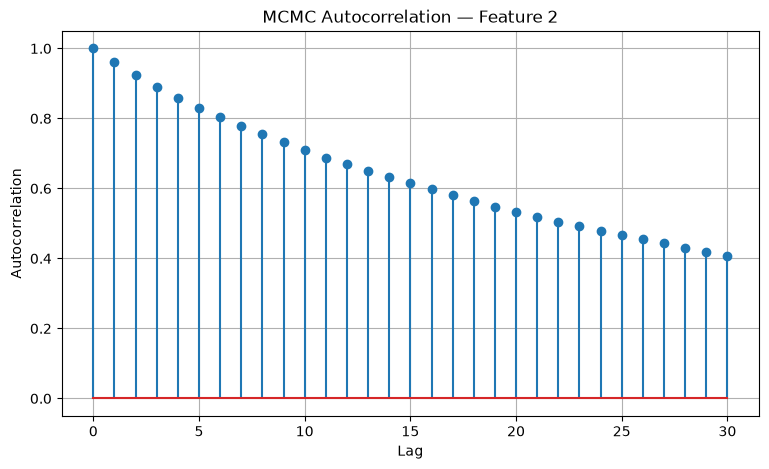

In [45]:
from statsmodels.tsa.stattools import acf

for i, name in enumerate(
    ["Intercept", "Feature 1", "Feature 2"]
):
    autocorrelations = acf(
        posterior_mcmc_samples[:, i],
        nlags=30,
        fft=True
    )

    plt.figure()

    plt.stem(
        range(len(autocorrelations)),
        autocorrelations
    )

    plt.xlabel("Lag")
    plt.ylabel("Autocorrelation")
    plt.title(f"MCMC Autocorrelation — {name}")

    plt.show()

## 60. Effective Sample Size

Because MCMC samples are correlated, the effective number of independent
samples can be much smaller than the total number of draws.

A common approximation is:

$$
ESS
\approx
\frac{N}
{1+2\sum_{k=1}^{\infty}\rho_k}
$$

where:

- $N$ is the number of MCMC samples.
- $\rho_k$ is the autocorrelation at lag $k$.

Therefore, a chain containing 10,000 samples may contain substantially fewer
than 10,000 effectively independent samples.

This is why simply increasing the number of MCMC iterations does not always
solve sampling problems.

In [46]:
def approximate_ess(samples, max_lag=100):
    samples = np.asarray(samples)

    acf_values = acf(
        samples,
        nlags=max_lag,
        fft=True
    )

    positive_acf = acf_values[1:]

    positive_acf = positive_acf[
        positive_acf > 0
    ]

    tau = 1 + 2 * np.sum(positive_acf)

    return len(samples) / tau


for i, name in enumerate(
    ["Intercept", "Feature 1", "Feature 2"]
):
    ess = approximate_ess(
        posterior_mcmc_samples[:, i]
    )

    print(f"{name}: ESS ≈ {ess:.0f}")

Intercept: ESS ≈ 322
Feature 1: ESS ≈ 259
Feature 2: ESS ≈ 211


## 61. Thinning

Thinning keeps every $k$-th MCMC sample.

For example:

$$
X_1,X_2,X_3,\ldots,X_{10000}
$$

could be thinned to:

$$
X_1,X_{11},X_{21},\ldots
$$

Thinning can reduce storage and visualization density, but it does **not**
automatically improve the statistical information contained in a fixed number
of MCMC computations.

In practice, improving the sampler and running a sufficiently long chain is
usually preferable to relying heavily on thinning.

## 62. Multiple MCMC Chains

A stronger convergence strategy is to run multiple chains from different
initial values.

If different chains converge to the same region of parameter space, this
provides evidence that the sampler is exploring the same posterior.

Suppose we have $M$ chains:

$$
\theta^{(1)},\theta^{(2)},\ldots,\theta^{(M)}
$$

A convergence diagnostic can compare:

- Within-chain variation
- Between-chain variation

This leads to the Gelman-Rubin diagnostic, commonly written as:

$$
\hat{R}
$$

A value close to:

$$
\hat{R}=1
$$

indicates that the chains have approximately mixed to the same distribution.

## Run Multiple Metropolis-Hastings Chains

In [47]:
initial_states = [
    np.zeros(n_features),
    np.ones(n_features),
    -np.ones(n_features),
    np.array([2.0, -2.0, 1.0])
]

chains = []
acceptance_rates = []

for initial_state in initial_states:

    chain, rate = metropolis_hastings(
        log_target=lambda beta: log_posterior(
            beta,
            X_train_design,
            y_train,
            prior_std
        ),
        initial_state=initial_state,
        n_samples=15_000,
        proposal_std=0.15,
        random_state=42
    )

    chains.append(chain)
    acceptance_rates.append(rate)

chains = np.array(chains)

print("Chain shape:", chains.shape)

for i, rate in enumerate(acceptance_rates, start=1):
    print(
        f"Chain {i} acceptance rate: {rate:.3f}"
    )

Chain shape: (4, 15000, 3)
Chain 1 acceptance rate: 0.672
Chain 2 acceptance rate: 0.672
Chain 3 acceptance rate: 0.671
Chain 4 acceptance rate: 0.670


## Compare Chain Means

In [48]:
chain_means = chains[:, 5_000:, :].mean(axis=1)

chain_summary = pd.DataFrame(
    chain_means,
    columns=[
        "Intercept",
        "Feature 1",
        "Feature 2"
    ]
)

chain_summary.index = [
    "Chain 1",
    "Chain 2",
    "Chain 3",
    "Chain 4"
]

chain_summary

,Intercept,Feature 1,Feature 2
Chain 1,-1.404365,0.183230,3.214481
Chain 2,-1.400876,0.191064,3.205266
Chain 3,-1.403795,0.182733,3.213319
Chain 4,-1.397480,0.177842,3.208346


If the chains have converged well, their posterior summaries should be
reasonably similar.

Large differences between chains suggest that more sampling, better tuning,
or a better parameterization may be necessary.

## 65. A Practical Bayesian Workflow

A robust Bayesian analysis generally follows:

$$
\boxed{
\text{Problem}
\rightarrow
\text{Prior}
\rightarrow
\text{Model}
\rightarrow
\text{Prior Predictive Check}
\rightarrow
\text{Inference}
\rightarrow
\text{Diagnostics}
\rightarrow
\text{Posterior Predictive Check}
\rightarrow
\text{Decision}
}
$$

This workflow is more important than memorizing individual Bayesian
algorithms.

The model should be checked both before and after observing the data.

## 66. Prior Predictive Distribution

Before observing data, we can ask:

> What kinds of observations does my prior imply?

The prior predictive distribution is:

$$
p(y)
=
\int
p(y\mid\theta)p(\theta)\,d\theta
$$

For regression:

$$
p(y\mid X)
=
\int
p(y\mid X,\beta)
p(\beta)\,d\beta
$$

A prior that produces absurd predictions may indicate that our prior is
poorly chosen.

Prior predictive checks are therefore a useful model-building tool.

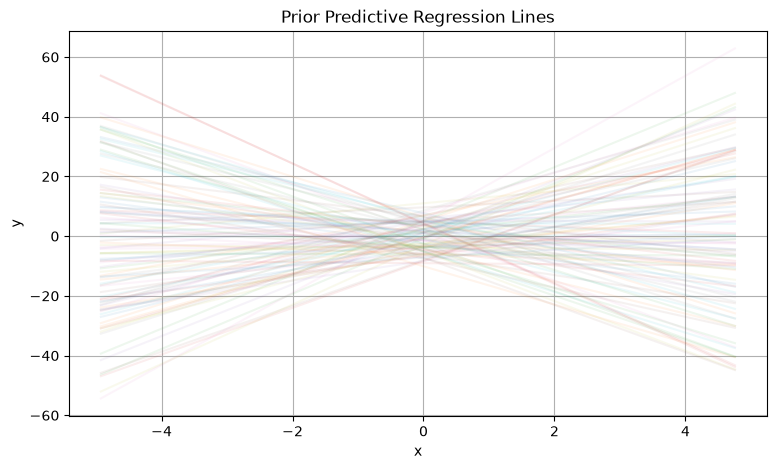

In [49]:
n_prior_samples = 300

prior_beta_samples = rng.multivariate_normal(
    mean=np.zeros(n_features),
    cov=np.eye(n_features) * prior_std**2,
    size=n_prior_samples
)

plt.figure()

for beta in prior_beta_samples[:100]:

    y_prior = (
        beta[0]
        + beta[1] * x_grid
    )

    plt.plot(
        x_grid,
        y_prior,
        alpha=0.08
    )

plt.xlabel("x")
plt.ylabel("y")
plt.title("Prior Predictive Regression Lines")

plt.show()

This visualization shows how strongly the prior influences the range of
models considered plausible before observing data.

A very wide prior can produce implausibly extreme predictions.

This is one reason Bayesian modeling requires thoughtful prior specification.

## 67. Probabilistic Programming with PyMC

For practical Bayesian modeling, probabilistic programming frameworks can
automate sophisticated inference algorithms.

We will use **PyMC** after implementing the core ideas manually.

The purpose is not to replace the mathematics.

Instead:

$$
\text{Mathematical understanding}
\rightarrow
\text{Implementation from scratch}
\rightarrow
\text{Probabilistic programming}
$$

This progression makes the library implementation much easier to understand.

In [50]:
try:
    import pymc as pm
    print("PyMC version:", pm.__version__)
except ImportError:
    print(
        "PyMC is not installed in the current environment."
    )

PyMC is not installed in the current environment.


## Bayesian Linear Regression with PyMC

In [54]:
with pm.Model() as bayesian_regression:

    beta_0 = pm.Normal(
        "beta_0",
        mu=0,
        sigma=10
    )

    beta_1 = pm.Normal(
        "beta_1",
        mu=0,
        sigma=10
    )

    sigma = pm.HalfNormal(
        "sigma",
        sigma=5
    )

    mu = beta_0 + beta_1 * X[:, 0]

    y_obs = pm.Normal(
        "y_obs",
        mu=mu,
        sigma=sigma,
        observed=y
    )

    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        cores=1,
        random_seed=42,
        progressbar=False
    )

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [beta_0, beta_1, sigma]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


## Posterior Summary

In [55]:
summary = pm.summary(
    trace,
    var_names=[
        "beta_0",
        "beta_1",
        "sigma"
    ]
)

summary

C:\Users\soumy\AppData\Local\Temp\ipykernel_14172\1031242211.py:1: DeprecationWarning: `pymc.summary` was moved out of the root namespace and will be removed in the first PyMC release of 2027. Use `pymc.stats.summary` instead.
  summary = pm.summary(


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta_0,0.484,0.044,0.41,0.56,1958,1817,1.00,0.001,0.00078
beta_1,0.012,0.0255,-0.029,0.052,1902,1821,1.00,0.00059,0.00047
sigma,0.5023,0.016,0.48,0.53,2339,2255,1.00,0.00033,0.0003


The summary typically includes quantities such as:

- Posterior mean
- Standard deviation
- Credible intervals
- Monte Carlo standard error
- Effective sample size
- $\hat{R}$

For a well-behaved model, we generally want:

$$
\hat{R}\approx1
$$

and sufficiently large effective sample sizes.

## Trace Plot with PyMC

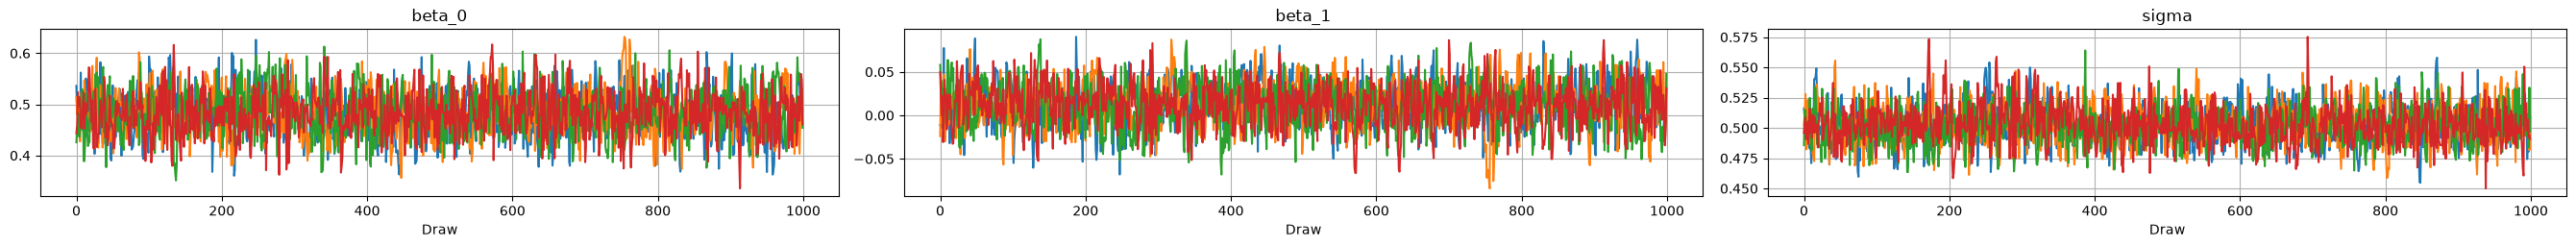

In [56]:
import arviz as az

az.plot_trace(
    trace,
    var_names=[
        "beta_0",
        "beta_1",
        "sigma"
    ]
)

plt.tight_layout()
plt.show()

## Posterior Distributions

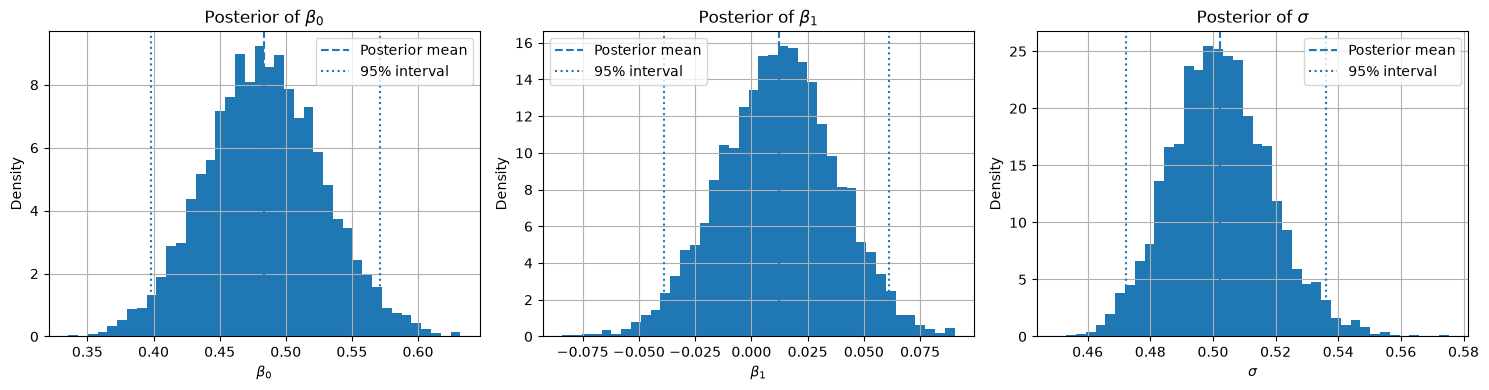

In [64]:
import matplotlib.pyplot as plt
import numpy as np

beta_0_samples = (
    trace.posterior["beta_0"]
    .values
    .ravel()
)

beta_1_samples = (
    trace.posterior["beta_1"]
    .values
    .ravel()
)

sigma_samples = (
    trace.posterior["sigma"]
    .values
    .ravel()
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

posterior_variables = [
    beta_0_samples,
    beta_1_samples,
    sigma_samples
]

posterior_names = [
    r"$\beta_0$",
    r"$\beta_1$",
    r"$\sigma$"
]

for ax, samples, name in zip(
    axes,
    posterior_variables,
    posterior_names
):

    ax.hist(
        samples,
        bins=40,
        density=True
    )

    mean = samples.mean()

    lower, upper = np.percentile(
        samples,
        [2.5, 97.5]
    )

    ax.axvline(
        mean,
        linestyle="--",
        label="Posterior mean"
    )

    ax.axvline(
        lower,
        linestyle=":",
        label="95% interval"
    )

    ax.axvline(
        upper,
        linestyle=":"
    )

    ax.set_xlabel(name)
    ax.set_ylabel("Density")
    ax.set_title(f"Posterior of {name}")
    ax.legend()

plt.tight_layout()
plt.show()

## 72. Posterior Predictive Sampling

After estimating the posterior, we can generate predictions from the posterior.

The posterior predictive distribution is:

$$
p(\tilde{y}\mid y)
=
\int
p(\tilde{y}\mid\theta)
p(\theta\mid y)
\,d\theta
$$

Rather than plugging in a single estimate of $\theta$, we sample from the
posterior and generate predictions for each sampled parameter configuration.

In [65]:
with bayesian_regression:
    posterior_predictive = pm.sample_posterior_predictive(
        trace,
        random_seed=42,
        progressbar=False
    )

Sampling: [y_obs]


In [69]:
y_pred = (
    posterior_predictive
    .posterior_predictive["y_obs"]
    .values
)

In [70]:
y_pred_flat = y_pred.reshape(-1, y_pred.shape[-1])

print("Flattened shape:", y_pred_flat.shape)

Flattened shape: (4000, 500)


## Posterior Predictive Check

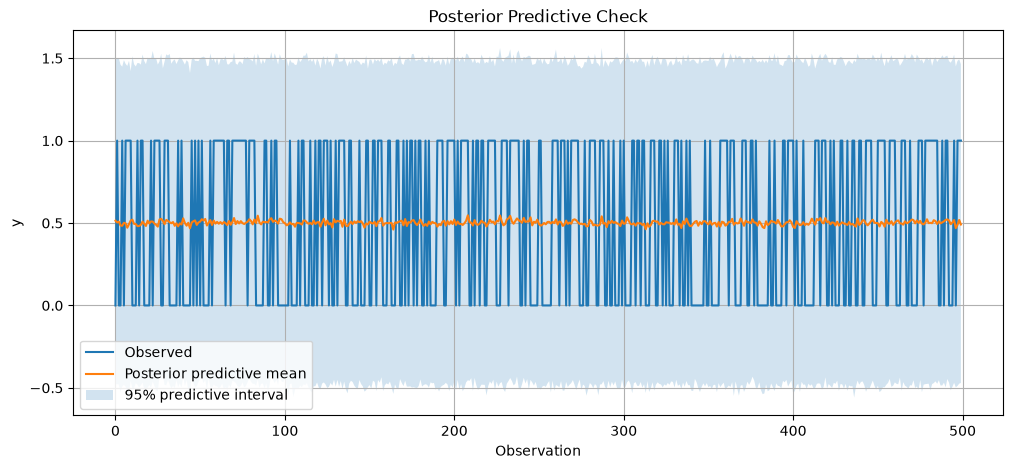

In [71]:
posterior_predictive_mean = y_pred_flat.mean(axis=0)

lower = np.percentile(
    y_pred_flat,
    2.5,
    axis=0
)

upper = np.percentile(
    y_pred_flat,
    97.5,
    axis=0
)

plt.figure(figsize=(12, 5))

plt.plot(
    y,
    label="Observed"
)

plt.plot(
    posterior_predictive_mean,
    label="Posterior predictive mean"
)

plt.fill_between(
    np.arange(len(y)),
    lower,
    upper,
    alpha=0.2,
    label="95% predictive interval"
)

plt.xlabel("Observation")
plt.ylabel("y")
plt.title("Posterior Predictive Check")
plt.legend()

plt.show()

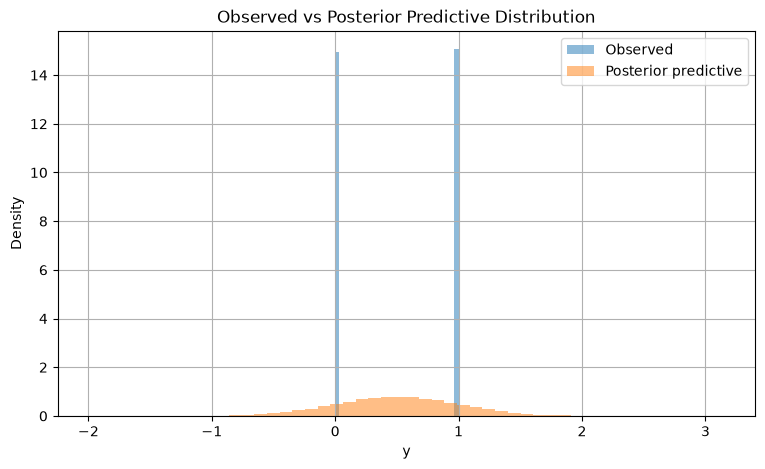

In [72]:
plt.figure(figsize=(9, 5))

plt.hist(
    y,
    bins=30,
    density=True,
    alpha=0.5,
    label="Observed"
)

plt.hist(
    y_pred_flat.ravel(),
    bins=50,
    density=True,
    alpha=0.5,
    label="Posterior predictive"
)

plt.xlabel("y")
plt.ylabel("Density")
plt.title("Observed vs Posterior Predictive Distribution")
plt.legend()

plt.show()

## 74. Prior Sensitivity Analysis

Bayesian inference depends on:

$$
\text{Posterior}
\propto
\text{Likelihood}
\times
\text{Prior}
$$

Therefore, we should investigate how conclusions change under reasonable
alternative priors.

We will compare:

1. Weak prior
2. Moderate prior
3. Strong prior

The goal is not to find a prior that produces the desired result.

The goal is to determine whether our conclusions are robust to reasonable
prior assumptions.

In [62]:
prior_stds = [
    1.0,
    5.0,
    20.0
]

prior_results = {}

for prior_std_value in prior_stds:

    with pm.Model() as model:

        beta_0 = pm.Normal(
            "beta_0",
            mu=0,
            sigma=prior_std_value
        )

        beta_1 = pm.Normal(
            "beta_1",
            mu=0,
            sigma=prior_std_value
        )

        sigma = pm.HalfNormal(
            "sigma",
            sigma=5
        )

        mu = beta_0 + beta_1 * X[:, 0]

        pm.Normal(
            "y_obs",
            mu=mu,
            sigma=sigma,
            observed=y
        )

        trace_prior = pm.sample(
            draws=800,
            tune=800,
            chains=2,
            random_seed=42,
            progressbar=False
        )

        prior_results[prior_std_value] = trace_prior

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta_0, beta_1, sigma]
Sampling 2 chains for 800 tune and 800 draw iterations (1_600 + 1_600 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta_0, beta_1, sigma]
Sampling 2 chains for 800 tune and 800 draw iterations (1_600 + 1_600 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta_0, beta_1, sigma]
Sampling 2 chains for 800 tune and 800 draw iterations (1_600 + 1_600 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


## Compare Posterior Slopes

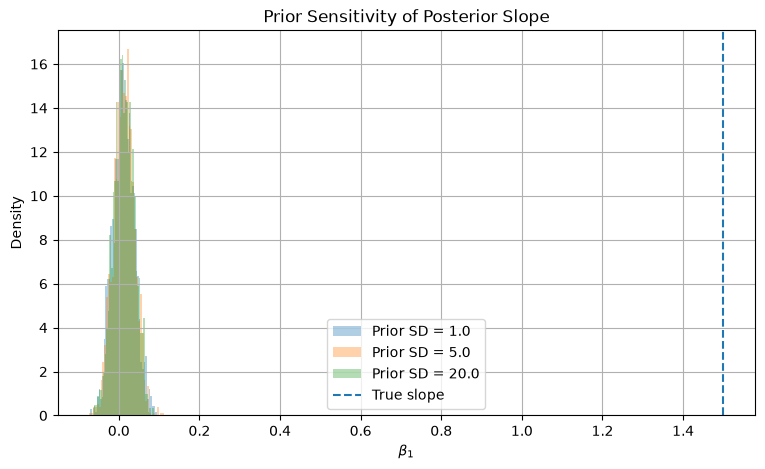

In [63]:
plt.figure()

for prior_std_value, trace_prior in prior_results.items():

    slope_samples = (
        trace_prior
        .posterior["beta_1"]
        .values
        .ravel()
    )

    plt.hist(
        slope_samples,
        bins=40,
        density=True,
        alpha=0.35,
        label=f"Prior SD = {prior_std_value}"
    )

plt.axvline(
    true_slope,
    linestyle="--",
    label="True slope"
)

plt.xlabel(r"$\beta_1$")
plt.ylabel("Density")
plt.title("Prior Sensitivity of Posterior Slope")
plt.legend()

plt.show()

With sufficient data, reasonable priors should often produce similar
posteriors.

With limited data, the prior can have a much stronger influence.

Therefore:

$$
\boxed{
\text{Prior sensitivity is especially important when data are weak}
}
$$

## 77. Bayesian Diagnostics Checklist

Before trusting a Bayesian model, check:

### Prior predictive behavior

Does the prior generate plausible data?

### MCMC trace

Do chains mix well?

### Acceptance rate

Is the sampler behaving reasonably?

### $\hat{R}$

Are multiple chains converging to approximately the same distribution?

$$
\hat{R}\approx1
$$

### Effective sample size

Are we obtaining enough effectively independent samples?

### Autocorrelation

Are samples excessively correlated?

### Posterior predictive checks

Can the fitted model reproduce important characteristics of the observed
data?

### Prior sensitivity

Do reasonable prior choices lead to substantially different conclusions?

A Bayesian analysis without diagnostics is incomplete.

## Summary

We have now built a complete Bayesian inference workflow.

### MCMC

MCMC generates samples approximately distributed according to:

$$
p(\theta\mid D)
$$

### Diagnostics

Important diagnostics include:

$$
\hat{R}
$$

effective sample size, trace plots, and autocorrelation.

### Probabilistic programming

PyMC allows us to express:

$$
\text{Prior}
+
\text{Likelihood}
=
\text{Bayesian Model}
$$

and use advanced inference algorithms without manually implementing every
sampling mechanism.

### Prior predictive checking

Before fitting:

$$
p(y)
=
\int p(y\mid\theta)p(\theta)d\theta
$$

should produce plausible outcomes.

### Posterior predictive checking

After fitting:

$$
p(\tilde y\mid D)
=
\int
p(\tilde y\mid\theta)
p(\theta\mid D)d\theta
$$

should reproduce important characteristics of the observed data.

### Main principle

A Bayesian model is not complete when the posterior has been sampled.

A proper workflow is:

$$
\boxed{
\text{Specify}
\rightarrow
\text{Fit}
\rightarrow
\text{Diagnose}
\rightarrow
\text{Check}
\rightarrow
\text{Interpret}
}
$$

## 79. Bayesian Model Comparison

Bayesian inference can also be used to compare competing models.

Suppose we have two models:

$$
M_1
$$

and

$$
M_2
$$

Bayesian model comparison considers:

$$
p(M\mid D)
\propto
p(D\mid M)p(M)
$$

where:

- $p(M)$ is the prior probability of the model.
- $p(D\mid M)$ is the marginal likelihood.
- $p(M\mid D)$ is the posterior probability of the model.

The marginal likelihood is:

$$
p(D\mid M)
=
\int
p(D\mid\theta,M)
p(\theta\mid M)
\,d\theta
$$

Unlike maximum likelihood, the marginal likelihood integrates over parameter
uncertainty.

This naturally introduces a complexity penalty: models that require large
regions of parameter space to explain the data can be penalized.

## 80. Bayes Factor

For two models, the Bayes factor is:

$$
BF_{12}
=
\frac{p(D\mid M_1)}
{p(D\mid M_2)}
$$

Interpretation:

- $BF_{12}>1$: evidence favors $M_1$.
- $BF_{12}<1$: evidence favors $M_2$.
- $BF_{12}\approx1$: little evidence differentiating the models.

The Bayes factor compares models through their marginal likelihoods.

A major practical limitation is that marginal likelihoods can be difficult
to compute accurately for complex models.

## 81. Predictive Model Comparison

In practical machine learning, we are often more interested in:

> Which model predicts future observations better?

rather than:

> Which model has the highest marginal likelihood?

Bayesian predictive evaluation can therefore use criteria such as:

- WAIC
- LOO-CV
- Posterior predictive performance

### WAIC

The Widely Applicable Information Criterion estimates out-of-sample predictive
performance while accounting for model complexity.

### LOO-CV

Leave-One-Out Cross-Validation estimates predictive performance by repeatedly
evaluating how well the model predicts observations that were excluded from
fitting.

These approaches are particularly useful when models have complex posterior
distributions.

## 82. Bayesian Decision Theory

Bayesian inference does not automatically tell us what action to take.

It gives us a posterior distribution.

Decision theory converts that uncertainty into an action.

Let:

- $a$ be an action.
- $\theta$ be the unknown state.
- $L(a,\theta)$ be the loss associated with taking action $a$.

The Bayesian optimal action minimizes posterior expected loss:

$$
a^*
=
\arg\min_a
E[L(a,\theta)\mid D]
$$

or:

$$
a^*
=
\arg\min_a
\int
L(a,\theta)
p(\theta\mid D)
\,d\theta
$$

Therefore:

$$
\boxed{
\text{Inference}
\rightarrow
\text{Decision}
}
$$

The optimal action depends not only on the posterior but also on the loss
function.

## 83. Bayesian Point Decisions

Different loss functions produce different optimal Bayesian decisions.

### Squared-error loss

Suppose:

$$
L(a,\theta)
=
(a-\theta)^2
$$

Then the optimal action is:

$$
a^*
=
E[\theta\mid D]
$$

Therefore, the posterior mean minimizes expected squared error.

### Absolute-error loss

For:

$$
L(a,\theta)
=
|a-\theta|
$$

the optimal action is the posterior median.

### 0-1 loss

For a discrete parameter or classification decision, 0-1 loss leads to the
posterior mode/MAP decision.

Thus, there is no universally best Bayesian point estimate.

The correct decision depends on the consequences of errors.

## 85. Uncertainty-Aware Classification

Bayesian models can represent uncertainty in predictions.

Suppose posterior samples give:

$$
p^{(1)},p^{(2)},\ldots,p^{(S)}
$$

for:

$$
P(y=1\mid x,D)
$$

We can calculate:

$$
\bar p
=
\frac{1}{S}
\sum_{s=1}^{S}p^{(s)}
$$

and a credible interval around the predictive probability.

A model may therefore say:

$$
P(y=1\mid x,D)
=
0.52
$$

but with substantial uncertainty.

This is different from a deterministic classifier simply returning:

$$
\hat y=1
$$

Bayesian prediction preserves information about uncertainty that can be
important in high-stakes decisions.

## 86. Predictive Entropy

For binary classification, predictive entropy is:

$$
H(Y\mid x,D)
=
-p\log p
-(1-p)\log(1-p)
$$

where:

$$
p=P(Y=1\mid x,D)
$$

Entropy is highest around:

$$
p=0.5
$$

and lowest near:

$$
p=0
$$

or:

$$
p=1
$$

Therefore predictive entropy can be used as a measure of classification
uncertainty.

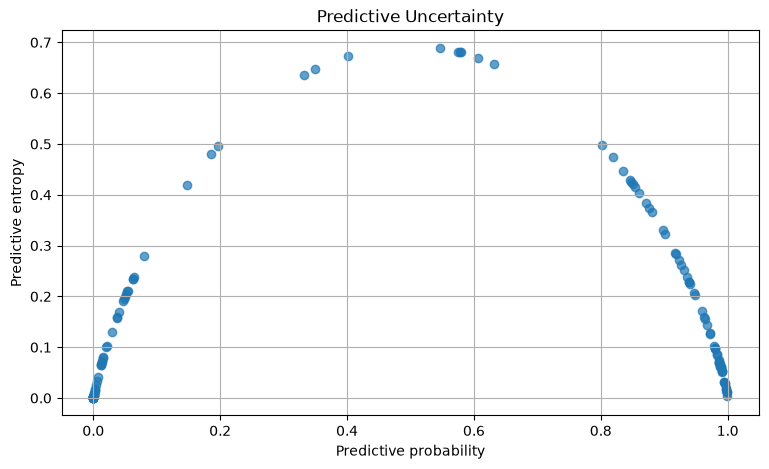

In [73]:
def binary_entropy(probabilities):
    probabilities = np.clip(
        probabilities,
        1e-12,
        1 - 1e-12
    )

    return -(
        probabilities * np.log(probabilities)
        + (1 - probabilities)
        * np.log(1 - probabilities)
    )


entropy = binary_entropy(
    predictive_mean
)

plt.figure()

plt.scatter(
    predictive_mean,
    entropy,
    alpha=0.7
)

plt.xlabel("Predictive probability")
plt.ylabel("Predictive entropy")
plt.title("Predictive Uncertainty")

plt.show()

## 87. Identifying the Most Uncertain Predictions

High predictive entropy identifies observations for which the classifier is
least certain.

This can be useful for:

- Human review
- Active learning
- Risk-sensitive classification
- Selective prediction
- Data quality investigation

In [74]:
most_uncertain_indices = np.argsort(
    entropy
)[-10:][::-1]

uncertain_predictions = pd.DataFrame({
    "Index": most_uncertain_indices,
    "True Label": y_test[most_uncertain_indices],
    "Predictive Probability": predictive_mean[
        most_uncertain_indices
    ],
    "Predictive Entropy": entropy[
        most_uncertain_indices
    ]
})

uncertain_predictions

,Index,True Label,Predictive Probability,Predictive Entropy
0,94,0,0.545920,0.688924
1,25,1,0.575001,0.681854
2,40,0,0.578277,0.680842
3,85,1,0.579662,0.680401
4,81,0,0.401313,0.673540
5,73,1,0.607153,0.670005
6,39,1,0.631638,0.658078
7,14,0,0.349003,0.646827
8,20,0,0.332532,0.635957
9,58,0,0.802400,0.497057


## 88. Bayesian vs Frequentist Learning

| Concept | Frequentist | Bayesian |
|---|---|---|
| Parameters | Fixed unknown quantities | Random variables representing uncertainty |
| Prior | Not used | Explicitly specified |
| Likelihood | Central | Central |
| Inference result | Point estimate / sampling distribution | Posterior distribution |
| Uncertainty | Sampling-based | Posterior-based |
| Prediction | Often based on estimated parameters | Integrates parameter uncertainty |
| Regularization | Penalty term | Can arise from a prior |
| Updating | Re-estimation | Posterior updating |
| Computation | Often simpler | Can require MCMC/approximation |
| Model checking | Residuals/CV/etc. | Prior/posterior predictive checks |
| Decision making | Separate framework | Naturally combined with posterior expected loss |

Neither paradigm is universally superior.

The appropriate choice depends on:

- Available data
- Domain knowledge
- Need for uncertainty quantification
- Computational resources
- Model complexity
- Decision consequences

## 89. Complete Bayesian Machine Learning Workflow

A practical Bayesian ML workflow can be summarized as:

$$
\boxed{
\begin{aligned}
&\text{1. Define the problem}\\
&\downarrow\\
&\text{2. Specify a generative model}\\
&\downarrow\\
&\text{3. Choose meaningful priors}\\
&\downarrow\\
&\text{4. Perform prior predictive checks}\\
&\downarrow\\
&\text{5. Observe data}\\
&\downarrow\\
&\text{6. Compute/approximate the posterior}\\
&\downarrow\\
&\text{7. Diagnose inference}\\
&\downarrow\\
&\text{8. Perform posterior predictive checks}\\
&\downarrow\\
&\text{9. Evaluate predictive performance}\\
&\downarrow\\
&\text{10. Quantify uncertainty}\\
&\downarrow\\
&\text{11. Make decisions using an appropriate loss function}
\end{aligned}
}
$$

This workflow emphasizes that Bayesian modeling is not simply:

$$
\text{Prior}\rightarrow\text{PyMC}\rightarrow\text{plot}
$$

The model must be checked and interpreted at every important stage.

## 90. Common Bayesian Mistakes

### 1. Treating the prior as objective truth

A prior is a modeling assumption.

It should be justified and subjected to sensitivity analysis.

### 2. Using an unnecessarily informative prior

Strong priors can dominate weak datasets.

### 3. Ignoring prior predictive behavior

A model can produce unreasonable predictions before seeing any data.

### 4. Assuming MCMC convergence automatically

A sampler finishing successfully does not prove convergence.

### 5. Looking only at posterior means

The posterior distribution contains substantially more information than a
single point estimate.

### 6. Ignoring posterior predictive checks

A model may have apparently reasonable parameter estimates while still
producing poor predictions.

### 7. Confusing credible intervals with confidence intervals

A Bayesian credible interval describes probability under the posterior:

$$
P(a\leq\theta\leq b\mid D)=0.95
$$

A frequentist confidence interval has a different interpretation based on
repeated sampling.

### 8. Using probability without considering decision costs

The best action depends on the loss function, not only on the predicted
probability.

## 91. Computational Considerations

Bayesian inference can become computationally expensive as models become more
complex.

Analytical inference is attractive when conjugacy is available:

$$
\text{Closed-form posterior}
\Rightarrow
\text{Fast inference}
$$

For non-conjugate models:

$$
\text{Approximate inference}
\Rightarrow
\text{Additional computation}
$$

MCMC can require thousands or millions of samples.

Computational cost depends on:

- Number of observations
- Number of parameters
- Posterior geometry
- Number of chains
- Number of draws
- Sampler efficiency
- Model complexity

Therefore Bayesian modeling requires both statistical and computational
reasoning.

## 92. Final Knowledge Check

You should now be able to answer the following questions.

### Conceptual

1. What is the difference between prior, likelihood, and posterior?
2. Why is the posterior proportional to likelihood times prior?
3. What is conjugacy?
4. Why does a Gaussian prior correspond to $L_2$ regularization under MAP?
5. What is the difference between MAP and full Bayesian inference?

### Computational

6. Why do logistic regression models require approximate Bayesian inference?
7. What problem does MCMC solve?
8. What is burn-in?
9. What does $\hat R$ measure?
10. Why does autocorrelation reduce effective sample size?

### Modeling

11. What is a prior predictive check?
12. What is a posterior predictive check?
13. Why should priors be subjected to sensitivity analysis?
14. When might a Bayesian model be preferable to a point-estimate model?

### Decision theory

15. Why does the optimal decision depend on the loss function?
16. Why might the optimal classification threshold differ from $0.5$?

If you can explain these concepts and reproduce the main experiments in this
notebook, you have a solid foundation in Bayesian machine learning.

# 93. Final Summary

Bayesian learning provides a unified framework for learning from data while
representing uncertainty.

The central equation is:

$$
p(\theta\mid D)
=
\frac{
p(D\mid\theta)p(\theta)
}{
p(D)
}
$$

From this foundation we developed:

$$
\boxed{
\text{Bayes' theorem}
\rightarrow
\text{Conjugate inference}
\rightarrow
\text{Bayesian regression}
\rightarrow
\text{MAP}
\rightarrow
\text{Laplace approximation}
\rightarrow
\text{MCMC}
\rightarrow
\text{Posterior prediction}
\rightarrow
\text{Decision theory}
}
$$

The most important conceptual progression is:

$$
\text{Point estimate}
\rightarrow
\text{Distribution over parameters}
\rightarrow
\text{Distribution over predictions}
\rightarrow
\text{Decision under uncertainty}
$$

Bayesian machine learning is therefore not simply a different way to train a
model.

It is a framework for reasoning about uncertainty throughout the entire
machine-learning pipeline.